# Analyse et Ingénierie des Données — Contamination au Chlordécone aux Antilles françaises

**DA03 — IDD | ENSAR | Année 1 Diplôme Ingénieur — Science de la donnée | 2025-2026**

---

## Contexte

La chlordécone est un pesticide organochloré utilisé massivement aux Antilles françaises, principalement en Martinique et en Guadeloupe, pour lutter contre le charançon du bananier. Son usage, autorisé jusqu'en 1993 malgré son interdiction aux États-Unis dès 1976, a entraîné une contamination durable et diffuse des sols, des eaux et des chaînes alimentaires. En raison de sa très forte persistance (demi-vie estimée entre 50 et 600 ans selon le type de sol), la chlordécone constitue aujourd'hui un enjeu sanitaire, environnemental et socio-économique de premier plan.

Ce projet exploite un jeu de données de **31 126 observations** portant sur des parcelles agricoles de Martinique, mesurées entre 2010 et 2019. Il couvre l'intégralité du pipeline d'ingénierie et d'analyse de données : chargement, nettoyage, transformation, jointures, analyse exploratoire, modélisation prédictive et restitution cartographique.

---


## 1. Chargement et exploration initiale

### 1.1 Imports et configuration

In [1]:
import subprocess, sys

# Installation silencieuse des dépendances manquantes
_pkgs = ["missingno", "scikit-learn", "scipy", "seaborn", "openpyxl"]
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--quiet", "--break-system-packages"] + _pkgs,
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
print("Dépendances vérifiées.")


Dépendances vérifiées.


In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, LogNorm
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kruskal, gaussian_kde, mannwhitneyu
import warnings
import re
from datetime import datetime

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import missingno as msno

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

# ─── Charte graphique globale ────────────────────────────────────────────────
DARK        = "#1A1A2E"
ACCENT      = "#E94560"
ORANGE      = "#F5A623"
GREEN       = "#27AE60"
BLUE        = "#2980B9"
GREY_LIGHT  = "#F2F3F4"
GREY_MID    = "#BDC3C7"
GREY_DARK   = "#7F8C8D"
TEXT_MAIN   = "#1C1C1C"
TEXT_SUB    = "#555555"
SEUIL_COLOR = "#C0392B"
SEUIL       = 0.1          # mg/kg — seuil réglementaire ANSES

PALETTE_CLD = ["#2ECC71", "#F39C12", "#C0392B"]
CLD_CMAP    = LinearSegmentedColormap.from_list("cld", ["#fffde7", "#ff9800", "#b71c1c"])

mpl.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.edgecolor":      "#DDDDDD",
    "axes.linewidth":      0.8,
    "axes.grid":           True,
    "grid.color":          "#EEEEEE",
    "grid.linewidth":      0.6,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "font.family":         "DejaVu Sans",
    "font.size":           10,
    "axes.labelsize":      10.5,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.titlepad":       14,
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "legend.frameon":      False,
    "legend.fontsize":     9,
    "figure.dpi":          130,
})

def bold_title(ax, title, subtitle=None):
    ax.set_title(title, fontweight="bold", fontsize=13, pad=12, loc="left")
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes,
                fontsize=9, color=TEXT_SUB, va="bottom")

print("Imports et charte graphique initialisés.")


Imports et charte graphique initialisés.


### 1.2 Chargement des données

In [3]:
# Chargement du fichier CSV — séparateur détecté automatiquement
df_raw = pd.read_csv("BaseCLD2026.csv", sep=None, engine="python", encoding="utf-8")

print(f"Dimensions brutes : {df_raw.shape[0]:,} lignes  ×  {df_raw.shape[1]} colonnes")
print(f"Colonnes : {list(df_raw.columns)}")
df_raw.head()


Dimensions brutes : 31,126 lignes  ×  22 colonnes
Colonnes : ['ID', 'ANNEE', 'COMMU_LAB', 'RAIN', 'Sol_simple', 'type_sol', 'Date_prelevement', 'Date_enregistrement', 'Date_analyse', 'Operateur_chld', 'Taux_Chlordecone', 'Operateur_5b', 'Taux_5b_hydro', 'histoBanane_Histo_ban', 'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean', 'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean', 'X', 'Y']


,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,Taux_Chlordecone,Operateur_5b,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,4.6000,=,"0,07",2.0000,5.8060,8.0334,21.5937,131.1740,79.4480,39.0431,714300.8319,1626343.5308
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,4.6000,=,"0,07",2.0000,5.6836,7.9206,20.9449,134.6082,76.9857,38.1237,714303.7433,1626353.9729
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,4.6000,=,"0,07",3.0000,2.2395,7.1084,20.0859,139.4205,76.0647,34.9767,714309.4468,1626360.3566
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,4.6000,=,"0,07",1.0000,4.0384,7.5301,23.4277,121.6037,92.3925,38.3158,714294.2085,1626321.3369
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,4.6000,=,"0,07",2.0000,0.5965,6.6371,20.1538,134.0651,83.9306,33.8777,714303.8231,1626340.5844


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31126 entries, 0 to 31125
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     31126 non-null  int64  
 1   ANNEE                  31126 non-null  int64  
 2   COMMU_LAB              30828 non-null  object 
 3   RAIN                   31126 non-null  object 
 4   Sol_simple             31052 non-null  object 
 5   type_sol               28517 non-null  object 
 6   Date_prelevement       31126 non-null  object 
 7   Date_enregistrement    31126 non-null  object 
 8   Date_analyse           31126 non-null  object 
 9   Operateur_chld         31126 non-null  object 
 10  Taux_Chlordecone       31126 non-null  float64
 11  Operateur_5b           31126 non-null  object 
 12  Taux_5b_hydro          31114 non-null  object 
 13  histoBanane_Histo_ban  13143 non-null  float64
 14  mnt_tpi_mean           31098 non-null  float64
 15  mn

In [5]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,31126.0000,NaN,NaN,NaN,38451.2704,19380.5471,20003.0000,21868.0000,23412.0000,62783.7500,63714.0000
ANNEE,31126.0000,NaN,NaN,NaN,2015.3190,2.8164,2010.0000,2013.0000,2016.0000,2018.0000,2019.0000
COMMU_LAB,30828,35,MORNE-ROUGE(LE),3725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAIN,31126,6,2000-3000,17425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sol_simple,31052,7,Andosol,10953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_sol,28517,41,Sols … allophane relativement peu ‚volu‚s,5794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_prelevement,31126,823,31/03/2017,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_enregistrement,31126,854,05/11/2014,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_analyse,31126,277,30/12/9999,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operateur_chld,31126,2,=,17533,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Qualité des données et nettoyage

### 2.1 Diagnostic des valeurs manquantes

In [6]:
# Tableau synthétique des valeurs manquantes
missing = pd.DataFrame({
    "manquants":  df_raw.isnull().sum(),
    "taux (%)":   (df_raw.isnull().mean() * 100).round(2),
    "dtype":      df_raw.dtypes
}).sort_values("taux (%)", ascending=False)

print("Colonnes avec valeurs manquantes :")
display(missing[missing["manquants"] > 0])
print(f"\n→ {missing['manquants'].sum()} valeurs manquantes au total "
      f"({missing['manquants'].sum() / df_raw.size * 100:.2f}% de la matrice)")


Colonnes avec valeurs manquantes :


,manquants,taux (%),dtype
histoBanane_Histo_ban,17983,57.7700,float64
type_sol,2609,8.3800,object
COMMU_LAB,298,0.9600,object
Sol_simple,74,0.2400,object
mnt_rugosite_mean,28,0.0900,float64
mnt_pente_mean,28,0.0900,float64
mnt_ombrage_mean,28,0.0900,float64
mnt_tpi_mean,28,0.0900,float64
mnt_tri_mean,28,0.0900,float64
mnt_exposition_mean,28,0.0900,float64



→ 21144 valeurs manquantes au total (3.09% de la matrice)


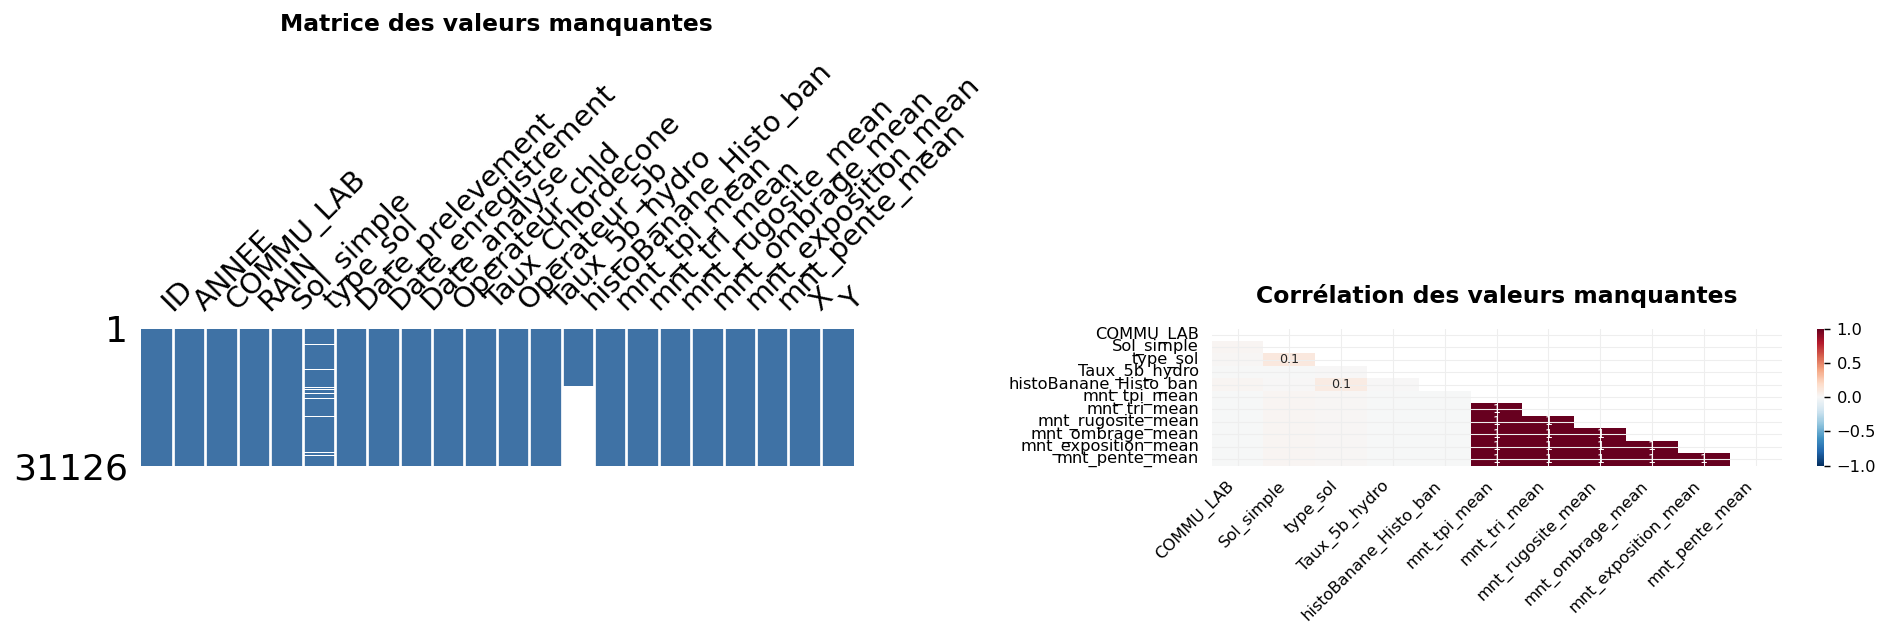

In [7]:
# Visualisation matricielle des valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

msno.matrix(df_raw, ax=axes[0], sparkline=False, color=(0.25, 0.45, 0.65))
axes[0].set_title("Matrice des valeurs manquantes", fontsize=13, fontweight="bold")

msno.heatmap(df_raw, ax=axes[1], cmap="RdBu_r", fontsize=9)
axes[1].set_title("Corrélation des valeurs manquantes", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("missing_analyse.png", dpi=130, bbox_inches="tight")
plt.show()


### 2.2 Détection d'incohérences

In [8]:
# ── Valeurs aberrantes et incohérences ───────────────────────────────────────
issues = {}

# Taux négatifs ou nuls
neg = df_raw[df_raw["Taux_Chlordecone"] <= 0]
issues["CLD <= 0"] = len(neg)

# Doublons stricts
issues["Doublons"] = df_raw.duplicated().sum()

# Coordonnées manquantes
issues["X ou Y manquant"] = df_raw[["X", "Y"]].isnull().any(axis=1).sum()

# Parcelles multi-années
suivi = df_raw.groupby("ID")["ANNEE"].nunique()
issues["Parcelles multi-années"] = (suivi > 1).sum()

for k, v in issues.items():
    print(f"  {k:<30} : {v:>6,}")

print()
print("Distribution du nombre d'années par parcelle :")
print(suivi.value_counts().sort_index().to_string())


  CLD <= 0                       :      0
  Doublons                       :      8
  X ou Y manquant                :      0
  Parcelles multi-années         :      0

Distribution du nombre d'années par parcelle :
ANNEE
1    3619


In [9]:
# ── Détection d'outliers — méthode IQR (seuil 3×IQR) ────────────────────────
Q1 = df_raw["Taux_Chlordecone"].quantile(0.25)
Q3 = df_raw["Taux_Chlordecone"].quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 3 * IQR

outliers = df_raw[df_raw["Taux_Chlordecone"] > borne_sup]
print(f"Seuil IQR (Q3 + 3×IQR) : {borne_sup:.3f} mg/kg")
print(f"Outliers : {len(outliers)} ({len(outliers)/len(df_raw)*100:.1f}%)")
print()
print(outliers[["ID", "ANNEE", "COMMU_LAB", "Sol_simple", "Taux_Chlordecone"]]
      .head(10).to_string(index=False))


Seuil IQR (Q3 + 3×IQR) : 1.633 mg/kg
Outliers : 4248 (13.6%)

   ID  ANNEE  COMMU_LAB Sol_simple  Taux_Chlordecone
20143   2010 GROS-MORNE    Andosol            4.6000
20143   2010 GROS-MORNE    Andosol            4.6000
20143   2010 GROS-MORNE    Andosol            4.6000
20143   2010 GROS-MORNE    Andosol            4.6000
20143   2010 GROS-MORNE    Andosol            4.6000
20143   2010 GROS-MORNE    Andosol            4.6000
20143   2010 GROS-MORNE    Andosol            4.6000
20124   2010 GROS-MORNE    Andosol            1.6600
20124   2010 GROS-MORNE    Andosol            1.6600
20124   2010 GROS-MORNE    Andosol            1.6600


### 2.3 Nettoyage et recodage

In [10]:
df = df_raw.copy()

# ── Correction de l'encodage latin-1 résiduel dans type_sol ─────────────────
def fix_encoding(text):
    if pd.isna(text):
        return text
    try:
        return text.encode("latin-1").decode("utf-8")
    except Exception:
        return text

df["type_sol"] = df["type_sol"].apply(fix_encoding)

# ── Conversion des dates ──────────────────────────────────────────────────────
for col in ["Date_prelevement", "Date_enregistrement", "Date_analyse"]:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

# ── Taux_5b_hydro : nettoyage (virgule → point, non-numériques → NaN) ────────
def parse_numeric_safe(val):
    """Convertit une valeur potentiellement mal formatée en float."""
    if pd.isna(val):
        return np.nan
    s = str(val).replace(",", ".").strip()
    try:
        f = float(s)
        return np.nan if np.isinf(f) else f
    except (ValueError, OverflowError):
        return np.nan

df["Taux_5b_hydro_num"] = df["Taux_5b_hydro"].apply(parse_numeric_safe)

# ── Sol_simple : normalisation des modalités non informatives ────────────────
df["Sol_simple"] = df["Sol_simple"].replace({"No data": np.nan, "Urban area": np.nan})

# ── Indicateurs de censure (valeur inférieure à la limite de détection) ──────
df["cld_censure"] = (df["Operateur_chld"] == "<").astype(int)
df["5b_censure"]  = (df["Operateur_5b"]   == "<").astype(int)

# ── COMMU_LAB : imputation par la modalité la plus fréquente ─────────────────
mode_commune = df["COMMU_LAB"].mode()[0]
nb_imputes   = df["COMMU_LAB"].isnull().sum()
df["COMMU_LAB"] = df["COMMU_LAB"].fillna(mode_commune)
print(f"COMMU_LAB : {nb_imputes} valeur(s) imputée(s) par '{mode_commune}'")

# ── histoBanane : recodage catégoriel ordonné ─────────────────────────────────
histo_map = {1.0: "Faible", 2.0: "Modéré", 3.0: "Intense"}
df["histo_banane_cat"] = (
    df["histoBanane_Histo_ban"]
    .map(histo_map)
    .fillna("Inconnu")
    .astype(pd.CategoricalDtype(["Faible","Modéré","Intense","Inconnu"], ordered=True))
)

print("Nettoyage terminé.")
print(f"Colonnes : {df.shape[1]} (dont {df.shape[1]-df_raw.shape[1]} nouvelles)")
df[["Date_prelevement","Taux_5b_hydro_num","cld_censure","histo_banane_cat"]].head()


COMMU_LAB : 298 valeur(s) imputée(s) par 'MORNE-ROUGE(LE)'
Nettoyage terminé.
Colonnes : 26 (dont 4 nouvelles)


,Date_prelevement,Taux_5b_hydro_num,cld_censure,histo_banane_cat
0,2007-05-24,0.0700,0,Modéré
1,2007-05-24,0.0700,0,Modéré
2,2007-05-24,0.0700,0,Intense
3,2007-05-24,0.0700,0,Faible
4,2007-05-24,0.0700,0,Modéré


In [11]:
# ── Imputation des variables topographiques par la médiane ───────────────────
topo_cols = ["mnt_tpi_mean", "mnt_tri_mean", "mnt_rugosite_mean",
             "mnt_ombrage_mean", "mnt_exposition_mean", "mnt_pente_mean"]

for col in topo_cols:
    mediane    = df[col].median()
    nb_imputes = df[col].isnull().sum()
    df[col]    = df[col].fillna(mediane)
    if nb_imputes > 0:
        print(f"{col:<30} → {nb_imputes} valeur(s) imputée(s) par la médiane ({mediane:.3f})")

print()
manquants_residuels = df.isnull().sum()
manquants_residuels = manquants_residuels[manquants_residuels > 0]
if len(manquants_residuels) > 0:
    print("Valeurs manquantes résiduelles :")
    print(manquants_residuels.to_string())
else:
    print("✓ Aucune valeur manquante résiduelle sur les variables topographiques.")


mnt_tpi_mean                   → 28 valeur(s) imputée(s) par la médiane (0.120)
mnt_tri_mean                   → 28 valeur(s) imputée(s) par la médiane (3.822)
mnt_rugosite_mean              → 28 valeur(s) imputée(s) par la médiane (12.000)
mnt_ombrage_mean               → 28 valeur(s) imputée(s) par la médiane (177.103)
mnt_exposition_mean            → 28 valeur(s) imputée(s) par la médiane (169.309)
mnt_pente_mean                 → 28 valeur(s) imputée(s) par la médiane (17.902)

Valeurs manquantes résiduelles :
Sol_simple                3403
type_sol                  2609
Date_analyse              2702
Taux_5b_hydro               12
histoBanane_Histo_ban    17983
Taux_5b_hydro_num          609


## 3. Transformation et ingénierie des variables

### 3.1 Variables temporelles

In [12]:
# ── Composantes temporelles ───────────────────────────────────────────────────
df["annee_prelevement"]     = df["Date_prelevement"].dt.year
df["mois_prelevement"]      = df["Date_prelevement"].dt.month
df["trimestre_prelevement"] = df["Date_prelevement"].dt.quarter
df["saison_prelevement"]    = df["mois_prelevement"].map(
    {12:"Hiver",1:"Hiver",2:"Hiver",
     3:"Printemps",4:"Printemps",5:"Printemps",
     6:"Été",7:"Été",8:"Été",
     9:"Automne",10:"Automne",11:"Automne"}
)

# Délai entre prélèvement et analyse (jours)
df["delai_analyse_jours"] = (df["Date_analyse"] - df["Date_prelevement"]).dt.days

# Cohérence temporelle : délais négatifs
n_incoherents = (df["delai_analyse_jours"] < 0).sum()
print(f"Délais analyse négatifs (incohérences) : {n_incoherents}")
df.loc[df["delai_analyse_jours"] < 0, "delai_analyse_jours"] = np.nan

df[["Date_prelevement","annee_prelevement","mois_prelevement",
    "trimestre_prelevement","saison_prelevement","delai_analyse_jours"]].head(6)


Délais analyse négatifs (incohérences) : 89


,Date_prelevement,annee_prelevement,mois_prelevement,trimestre_prelevement,saison_prelevement,delai_analyse_jours
0,2007-05-24,2007,5,2,Printemps,0.0000
1,2007-05-24,2007,5,2,Printemps,0.0000
2,2007-05-24,2007,5,2,Printemps,0.0000
3,2007-05-24,2007,5,2,Printemps,0.0000
4,2007-05-24,2007,5,2,Printemps,0.0000
5,2007-05-24,2007,5,2,Printemps,0.0000


### 3.2 Variables dérivées et transformation de la variable cible

In [13]:
# ── Transformation logarithmique (distribution log-normale) ──────────────────
df["log_cld"] = np.log1p(df["Taux_Chlordecone"])

# ── Classes de contamination réglementaires (seuils ANSES) ───────────────────
def classe_contamination(val):
    if val < 0.1:  return "Non contaminé"
    elif val < 1.0: return "Contaminé modéré"
    else:           return "Fortement contaminé"

df["classe_cld"] = df["Taux_Chlordecone"].apply(classe_contamination)
df["classe_cld"] = df["classe_cld"].astype(
    pd.CategoricalDtype(["Non contaminé","Contaminé modéré","Fortement contaminé"], ordered=True)
)

# ── Ratio CLD / 5b-hydroxychlordiécone ───────────────────────────────────────
df["ratio_cld_5b"] = df["Taux_Chlordecone"] / (df["Taux_5b_hydro_num"] + 1e-9)

# ── Catégorie de pente (switch / match-case Python 3.10+) ────────────────────
def categorie_pente(p):
    match True:
        case _ if p <  5: return "Plat"
        case _ if p < 15: return "Peu pentu"
        case _ if p < 30: return "Pentu"
        case _:           return "Très pentu"

df["cat_pente"]    = df["mnt_pente_mean"].apply(categorie_pente)
df["pente_forte"]  = (df["mnt_pente_mean"] > 30).astype(int)

# ── Résumé ────────────────────────────────────────────────────────────────────
print("Distribution des classes de contamination :")
print(df["classe_cld"].value_counts().to_string())
print()
print("Distribution de l'historique bananier :")
print(df["histo_banane_cat"].value_counts().to_string())
print()
print("Distribution des catégories de pente :")
print(df["cat_pente"].value_counts().to_string())


Distribution des classes de contamination :
classe_cld
Non contaminé          20334
Fortement contaminé     5564
Contaminé modéré        5228

Distribution de l'historique bananier :
histo_banane_cat
Inconnu    17983
Faible      6370
Modéré      4697
Intense     2076

Distribution des catégories de pente :
cat_pente
Pentu         12727
Peu pentu     10078
Très pentu     5945
Plat           2376


### 3.3 Extraction de sous-ensembles et filtres

In [14]:
# ── group_by / summarise / filter ─────────────────────────────────────────────
# Andosols fortement contaminés
andosol_fort = df[
    (df["Sol_simple"] == "Andosol") &
    (df["classe_cld"] == "Fortement contaminé")
].copy()

print(f"Andosol fortement contaminé : {len(andosol_fort):,} parcelles")
print(f"CLD moyen                   : {andosol_fort['Taux_Chlordecone'].mean():.3f} mg/kg")
print(f"CLD médian                  : {andosol_fort['Taux_Chlordecone'].median():.3f} mg/kg")
print()

# Top 10 communes — médiane décroissante
top_communes = (
    df.groupby("COMMU_LAB")["Taux_Chlordecone"]
    .agg(n="count", mediane="median", moyenne="mean",
         pct_fort=lambda x: (x > 1.0).mean() * 100)
    .sort_values("mediane", ascending=False)
    .head(10)
    .reset_index()
)
print("Top 10 communes (médiane CLD) :")
display(top_communes.round(4))


Andosol fortement contaminé : 3,566 parcelles
CLD moyen                   : 3.579 mg/kg
CLD médian                  : 2.900 mg/kg

Top 10 communes (médiane CLD) :


,COMMU_LAB,n,mediane,moyenne,pct_fort
0,MORNE-ROUGE(LE),4023,2.3000,2.6164,59.0107
1,MACOUBA,698,1.5000,1.6966,65.0430
2,GRAND'RIVIERE,125,0.3363,1.8399,36.8000
3,LORRAIN(LE),1763,0.1850,0.5839,12.2518
4,MARIGOT(LE),475,0.1250,0.6131,28.4211
5,BASSE-POINTE,992,0.0900,1.3810,33.7702
6,Hors Martinique,27,0.0630,0.0821,0.0000
7,TRINITE(LA),1101,0.0600,0.6842,28.6104
8,SAINT-ESPRIT,1393,0.0400,0.3329,8.7581
9,SAINTE-MARIE,1406,0.0190,0.3405,10.8819


## 4. Jointures de données

Deux tables de référence sont construites pour illustrer les différents types de jointures.

In [15]:
# ── Tables de référence ───────────────────────────────────────────────────────
ref_pluvio = pd.DataFrame({
    "RAIN":          ["0-1250","1250-1500","1500-2000","2000-3000","3000-5000","5000-8000"],
    "pluvio_label":  ["Très sec","Sec","Sub-humide","Humide","Très humide","Hyper-humide"],
    "pluvio_mm_mid": [625, 1375, 1750, 2500, 4000, 6500]
})

ref_sol = pd.DataFrame({
    "Sol_simple":         ["Andosol","Ferralsol","Nitisol","Vertisol","Alluvium, Colluvium"],
    "retention_cld":      ["Très forte","Forte","Modérée","Faible","Variable"],
    "origine_volcanique": [True, True, True, False, False]
})

display(ref_pluvio)
display(ref_sol)


,RAIN,pluvio_label,pluvio_mm_mid
0,0-1250,Très sec,625
1,1250-1500,Sec,1375
2,1500-2000,Sub-humide,1750
3,2000-3000,Humide,2500
4,3000-5000,Très humide,4000
5,5000-8000,Hyper-humide,6500


,Sol_simple,retention_cld,origine_volcanique
0,Andosol,Très forte,True
1,Ferralsol,Forte,True
2,Nitisol,Modérée,True
3,Vertisol,Faible,False
4,"Alluvium, Colluvium",Variable,False


In [16]:
# ── Démonstration des quatre types de jointure ────────────────────────────────
df_left  = df.merge(ref_pluvio, on="RAIN",      how="left")
df_inner = df.merge(ref_sol,    on="Sol_simple", how="inner")
df_right = df.merge(ref_sol,    on="Sol_simple", how="right")
df_full  = df.merge(ref_sol,    on="Sol_simple", how="outer")

print(f"{'Jointure':<12}  {'Lignes':>8}  {'Impact'}")
print("-" * 55)
print(f"{'LEFT':<12}  {len(df_left):>8,}  Toutes les parcelles conservées")
print(f"{'INNER':<12}  {len(df_inner):>8,}  Parcelles avec Sol_simple connu uniquement")
print(f"{'RIGHT':<12}  {len(df_right):>8,}  Tous les types de sol représentés")
print(f"{'FULL':<12}  {len(df_full):>8,}  Union complète")

# Vérification : types de sol de la référence absents des données
manquants = df_right[df_right["ID"].isna()]["Sol_simple"].unique()
if len(manquants):
    print(f"\nTypes de sol dans ref_sol sans parcelle : {manquants}")
else:
    print("\n✓ Tous les types de sol de la référence sont représentés dans les données.")

# Enrichissement du dataframe principal
df = df.merge(ref_pluvio, on="RAIN",      how="left")
df = df.merge(ref_sol,    on="Sol_simple", how="left")
df["rain_mm"] = df["RAIN"].map(
    {"0-1250":625,"1250-1500":1375,"1500-2000":1750,
     "2000-3000":2500,"3000-5000":4000,"5000-8000":6500}
)
print(f"\nDataframe enrichi : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")


Jointure        Lignes  Impact
-------------------------------------------------------
LEFT            31,126  Toutes les parcelles conservées
INNER           27,723  Parcelles avec Sol_simple connu uniquement
RIGHT           27,723  Tous les types de sol représentés
FULL            31,126  Union complète

✓ Tous les types de sol de la référence sont représentés dans les données.

Dataframe enrichi : 31,126 lignes × 41 colonnes


## 5. Flux de contrôle et programmation fonctionnelle

### 5.1 Structures de contrôle

In [17]:
# ── Boucle for : statistiques par commune ─────────────────────────────────────
resultats_communes = []

for commune in sorted(df["COMMU_LAB"].dropna().unique()):
    sous_df = df[df["COMMU_LAB"] == commune]
    resultats_communes.append({
        "commune":               commune,
        "n_obs":                 len(sous_df),
        "mediane":               round(sous_df["Taux_Chlordecone"].median(), 4),
        "moyenne":               round(sous_df["Taux_Chlordecone"].mean(),   4),
        "max":                   round(sous_df["Taux_Chlordecone"].max(),    4),
        "pct_fort_contamination":round((sous_df["classe_cld"] == "Fortement contaminé").mean()*100, 1)
    })

stats_communes = (
    pd.DataFrame(resultats_communes)
    .sort_values("mediane", ascending=False)
    .reset_index(drop=True)
)
print("Statistiques par commune (top 15) :")
display(stats_communes.head(15))


Statistiques par commune (top 15) :


,commune,n_obs,mediane,moyenne,max,pct_fort_contamination
0,MORNE-ROUGE(LE),4023,2.3000,2.6164,17.3500,59.0000
1,MACOUBA,698,1.5000,1.6966,5.3100,65.0000
2,GRAND'RIVIERE,125,0.3363,1.8399,15.5150,36.8000
3,LORRAIN(LE),1763,0.1850,0.5839,12.7790,12.3000
4,MARIGOT(LE),475,0.1250,0.6131,2.0000,28.4000
5,BASSE-POINTE,992,0.0900,1.3810,9.3000,33.8000
6,Hors Martinique,27,0.0630,0.0821,0.1210,0.0000
7,TRINITE(LA),1101,0.0600,0.6842,3.6000,28.6000
8,SAINT-ESPRIT,1393,0.0400,0.3329,4.5400,9.0000
9,SAINTE-MARIE,1406,0.0190,0.3405,4.2700,10.9000


In [18]:
# ── Boucle while : seuil de pente à partir duquel la médiane CLD dépasse 0.5 ─
seuil_pente    = 5
max_pente      = int(df["mnt_pente_mean"].max())
seuil_critique = None

while seuil_pente <= max_pente:
    med = df[df["mnt_pente_mean"] >= seuil_pente]["Taux_Chlordecone"].median()
    if med > 0.5:
        seuil_critique = seuil_pente
        break
    seuil_pente += 5

if seuil_critique:
    med_critique = df[df["mnt_pente_mean"] >= seuil_critique]["Taux_Chlordecone"].median()
    print(f"Seuil de pente critique : {seuil_critique}°")
    print(f"Médiane CLD au-delà : {med_critique:.3f} mg/kg")
else:
    print("Aucun seuil critique trouvé.")


Seuil de pente critique : 60°
Médiane CLD au-delà : 1.618 mg/kg


### 5.2 Programmation fonctionnelle

In [19]:
# ── apply : normalisation min-max des variables topographiques ────────────────
topo_cols = ["mnt_tpi_mean","mnt_tri_mean","mnt_rugosite_mean",
             "mnt_ombrage_mean","mnt_exposition_mean","mnt_pente_mean"]

def minmax(serie):
    return (serie - serie.min()) / (serie.max() - serie.min() + 1e-12)

df[topo_cols] = df[topo_cols].apply(minmax)

print("Variables topographiques normalisées min-max :")
display(df[topo_cols].describe().round(4))


Variables topographiques normalisées min-max :


,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean
count,31126.0000,31126.0000,31126.0000,31126.0000,31126.0000,31126.0000
mean,0.5316,0.1469,0.1574,0.6526,0.4738,0.1622
std,0.0468,0.0973,0.1010,0.1211,0.2665,0.1070
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.5118,0.0809,0.0878,0.5849,0.2500,0.0865
50%,0.5299,0.1302,0.1405,0.6616,0.4714,0.1433
75%,0.5507,0.1916,0.2079,0.7318,0.6939,0.2168
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [20]:
# ── map : recodage via dictionnaire ──────────────────────────────────────────
rain_num_map = {"0-1250":625,"1250-1500":1375,"1500-2000":1750,
                "2000-3000":2500,"3000-5000":4000,"5000-8000":6500}
df["rain_mm"] = df["RAIN"].map(rain_num_map)

# ── Recherche ciblée — query ──────────────────────────────────────────────────
critiques_humides = df.query(
    "Taux_Chlordecone > 10 and pluvio_label in ['Humide','Très humide','Hyper-humide']"
)[["ID","COMMU_LAB","ANNEE","Sol_simple","Taux_Chlordecone","pluvio_label"]]

print(f"Parcelles critiques en zone humide (CLD > 10 mg/kg) : {len(critiques_humides)}")
display(critiques_humides.to_string(index=False))


Parcelles critiques en zone humide (CLD > 10 mg/kg) : 114


"   ID       COMMU_LAB  ANNEE Sol_simple  Taux_Chlordecone pluvio_label\n21121 MORNE-ROUGE(LE)   2011    Andosol           12.7000       Humide\n21121 MORNE-ROUGE(LE)   2011    Andosol           12.7000  Très humide\n21121 MORNE-ROUGE(LE)   2011    Andosol           12.7000       Humide\n21121 MORNE-ROUGE(LE)   2011    Andosol           12.7000  Très humide\n22387 MORNE-ROUGE(LE)   2015    Andosol           11.1540       Humide\n22387 MORNE-ROUGE(LE)   2015    Andosol           11.1540       Humide\n22387 MORNE-ROUGE(LE)   2015    Andosol           11.1540  Très humide\n22387 MORNE-ROUGE(LE)   2015    Andosol           11.1540  Très humide\n22387 MORNE-ROUGE(LE)   2015    Andosol           11.1540       Humide\n22387 MORNE-ROUGE(LE)   2015    Andosol           11.1540  Très humide\n22390 MORNE-ROUGE(LE)   2015    Andosol           10.0340       Humide\n22390 MORNE-ROUGE(LE)   2015    Andosol           10.0340  Très humide\n22390 MORNE-ROUGE(LE)   2015    Andosol           10.0340      

## 6. Analyse exploratoire et visualisations

### 6.1 Distribution de la variable cible

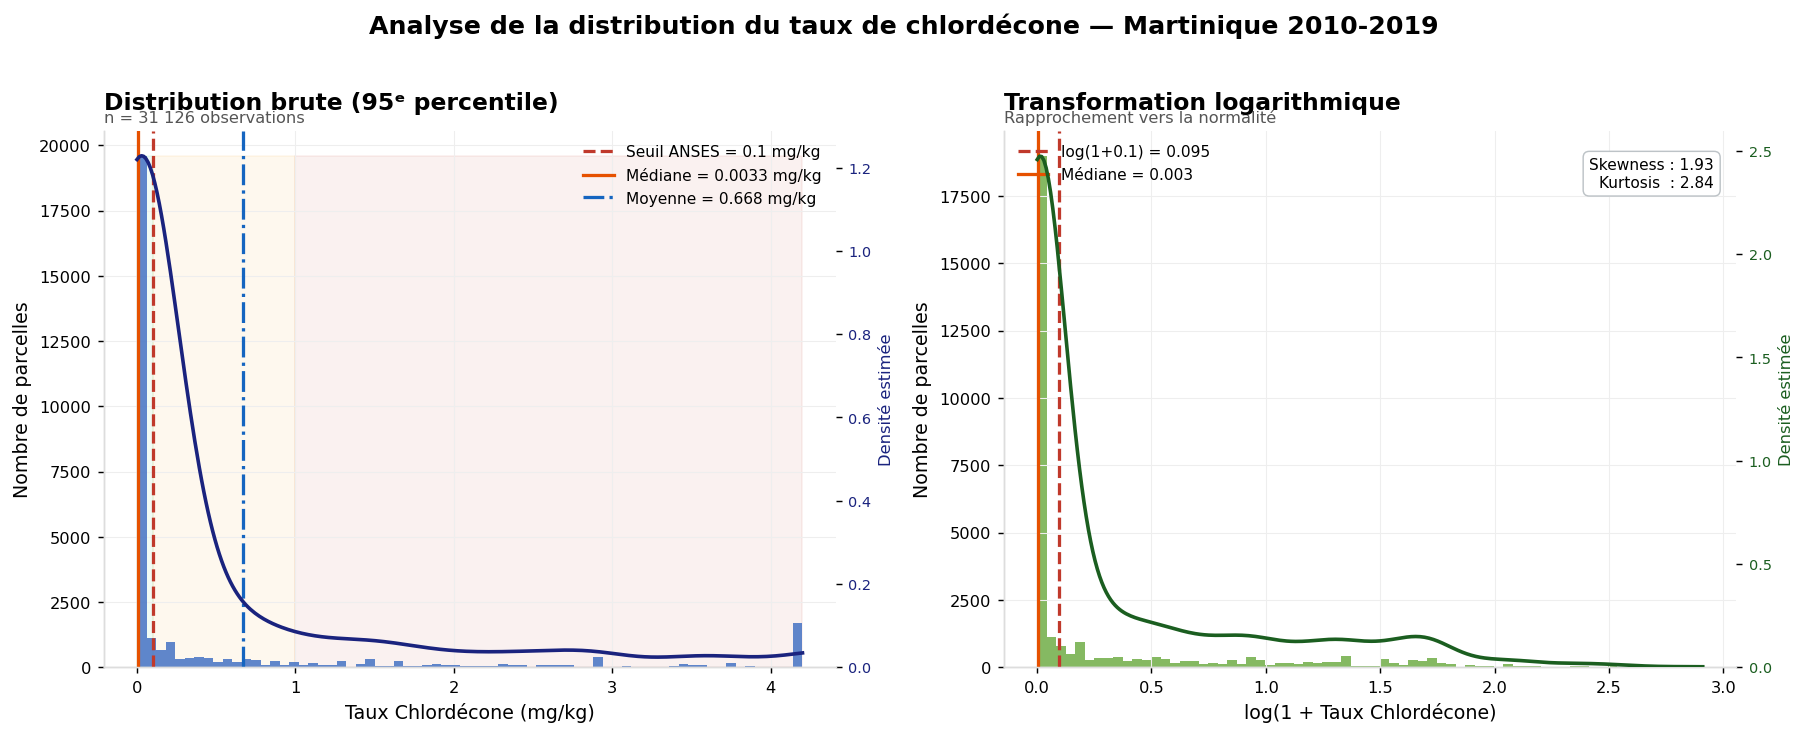

Shapiro-Wilk — W=0.6260, p=1.6314e-54
→ Distribution significativement non-normale


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor("white")

# ── Distribution brute (zoom 95ᵉ percentile) ──────────────────────────────────
clip   = df["Taux_Chlordecone"].quantile(0.95)
data_c = df["Taux_Chlordecone"].clip(upper=clip)

ax = axes[0]
n, bins, _ = ax.hist(data_c, bins=70, color="#4472C4", edgecolor="none", alpha=0.85, zorder=2)
kde_x = np.linspace(0, clip, 300)
kde   = gaussian_kde(df["Taux_Chlordecone"].dropna(), bw_method=0.15)
ax2   = ax.twinx()
ax2.plot(kde_x, kde(kde_x), color="#1A237E", lw=2, zorder=3)
ax2.set_ylim(0); ax2.set_ylabel("Densité estimée", color="#1A237E", fontsize=9)
ax2.tick_params(axis="y", labelcolor="#1A237E", labelsize=8)
ax2.spines["top"].set_visible(False); ax2.grid(False)

med, moy = df["Taux_Chlordecone"].median(), df["Taux_Chlordecone"].mean()
ax.axvline(SEUIL, color=SEUIL_COLOR, lw=1.8, ls="--", zorder=4, label=f"Seuil ANSES = {SEUIL} mg/kg")
ax.axvline(med,   color="#E65100",   lw=1.8, ls="-",  zorder=4, label=f"Médiane = {med:.4f} mg/kg")
ax.axvline(moy,   color="#1565C0",   lw=1.8, ls="-.", zorder=4, label=f"Moyenne = {moy:.3f} mg/kg")

for xmin, xmax, col in [(0, SEUIL, "#2ECC71"), (SEUIL, 1.0, "#F39C12"), (1.0, clip, "#C0392B")]:
    ax.fill_betweenx([0, n.max()], xmin, min(xmax, clip), color=col, alpha=0.07, zorder=1)

ax.set_xlabel("Taux Chlordécone (mg/kg)"); ax.set_ylabel("Nombre de parcelles")
ax.legend(loc="upper right", fontsize=8.5)
bold_title(ax, "Distribution brute (95ᵉ percentile)", "n = 31 126 observations")

# ── Distribution log-transformée ──────────────────────────────────────────────
ax = axes[1]
log_data = df["log_cld"].dropna()
n2, _, _ = ax.hist(log_data, bins=70, color="#70AD47", edgecolor="none", alpha=0.85)
kde2   = gaussian_kde(log_data, bw_method=0.2)
kde2_x = np.linspace(log_data.min(), log_data.max(), 300)
ax3    = ax.twinx()
ax3.plot(kde2_x, kde2(kde2_x), color="#1B5E20", lw=2, zorder=3)
ax3.set_ylim(0); ax3.set_ylabel("Densité estimée", color="#1B5E20", fontsize=9)
ax3.tick_params(axis="y", labelcolor="#1B5E20", labelsize=8)
ax3.spines["top"].set_visible(False); ax3.grid(False)

ax.axvline(np.log1p(SEUIL), color=SEUIL_COLOR, lw=1.8, ls="--", zorder=4,
           label=f"log(1+{SEUIL}) = {np.log1p(SEUIL):.3f}")
ax.axvline(log_data.median(), color="#E65100", lw=1.8, zorder=4,
           label=f"Médiane = {log_data.median():.3f}")
sk, ku = stats.skew(log_data), stats.kurtosis(log_data)
ax.text(0.97, 0.95, f"Skewness : {sk:.2f}\nKurtosis  : {ku:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=GREY_MID, lw=0.8))
ax.set_xlabel("log(1 + Taux Chlordécone)"); ax.set_ylabel("Nombre de parcelles")
ax.legend(loc="upper left", fontsize=8.5)
bold_title(ax, "Transformation logarithmique", "Rapprochement vers la normalité")

fig.suptitle("Analyse de la distribution du taux de chlordécone — Martinique 2010-2019",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_distribution.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# Test de normalité sur un échantillon
sample     = log_data.sample(n=min(2000, len(log_data)), random_state=42)
stat, p    = shapiro(sample)
print(f"Shapiro-Wilk — W={stat:.4f}, p={p:.4e}")
print("→ Distribution significativement non-normale" if p < 0.05
      else "→ Distribution compatible avec la normalité")


### 6.2 Contamination par type de sol

Kruskal-Wallis — H=4474.42, p=0.00e+00
→ Différences significatives entre types de sol


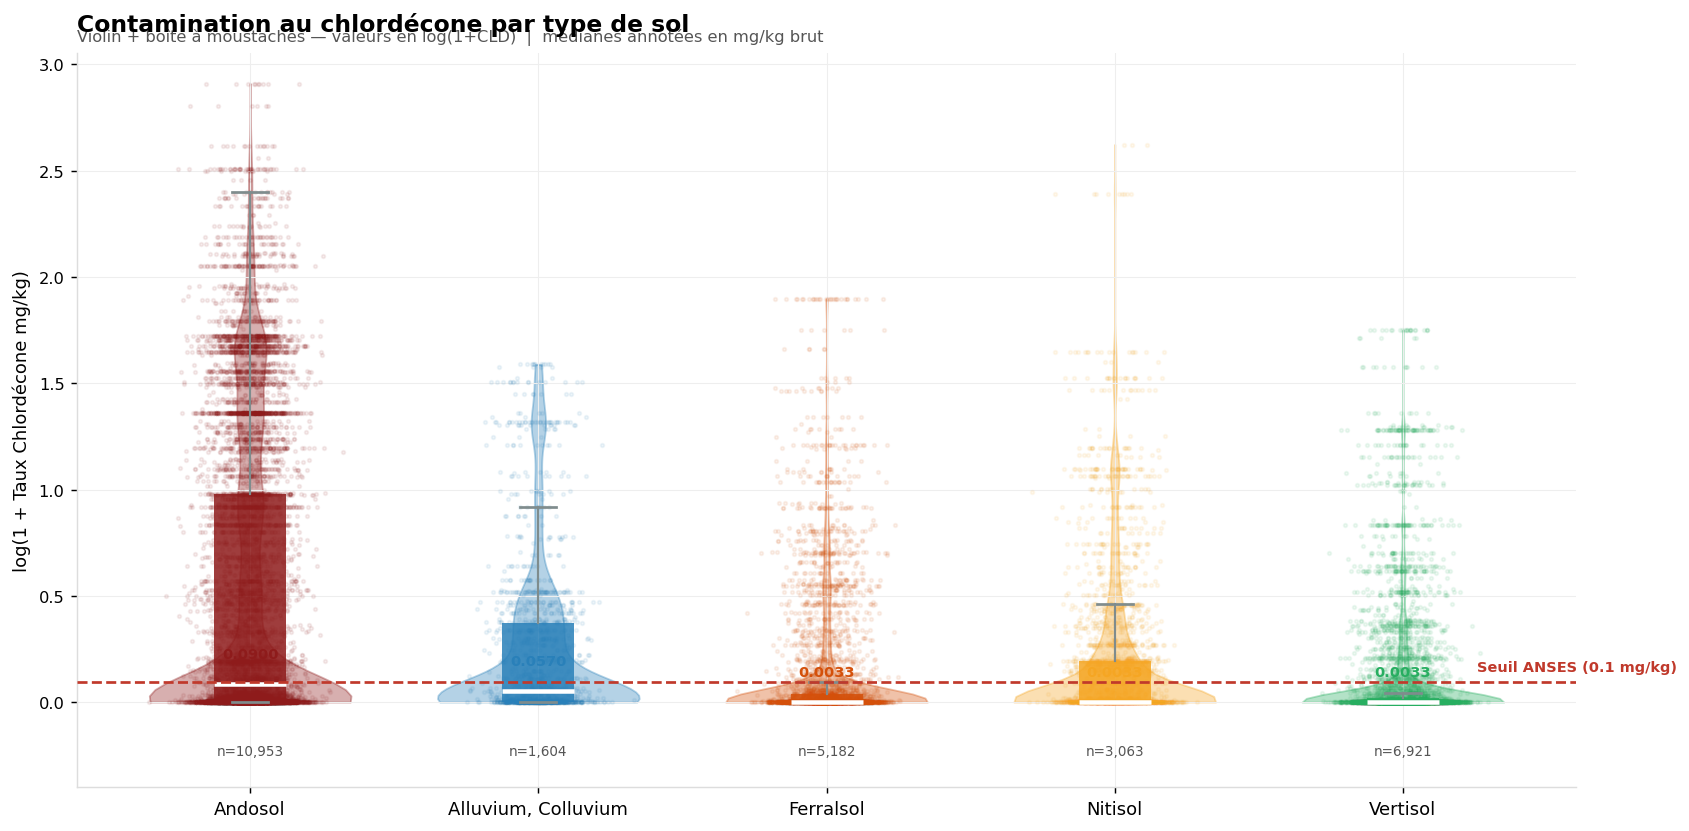

In [22]:
df_sol    = df.dropna(subset=["Sol_simple"]).copy()
ordre_sol = (df_sol.groupby("Sol_simple")["Taux_Chlordecone"]
             .median().sort_values(ascending=False).index.tolist())
sol_colors = {
    "Andosol":             "#8E1B1B",
    "Ferralsol":           "#D4500A",
    "Nitisol":             "#F5A623",
    "Vertisol":            "#27AE60",
    "Alluvium, Colluvium": "#2980B9",
}
default_color = "#7F8C8D"

fig, ax = plt.subplots(figsize=(13, 6.5))

vp = ax.violinplot(
    [np.log1p(df_sol[df_sol["Sol_simple"]==s]["Taux_Chlordecone"]) for s in ordre_sol],
    positions=range(len(ordre_sol)), widths=0.7, showmedians=False, showextrema=False
)
for body, sol in zip(vp["bodies"], ordre_sol):
    c = sol_colors.get(sol, default_color)
    body.set_facecolor(c); body.set_alpha(0.35); body.set_edgecolor(c); body.set_linewidth(1)

bp = ax.boxplot(
    [np.log1p(df_sol[df_sol["Sol_simple"]==s]["Taux_Chlordecone"]) for s in ordre_sol],
    positions=range(len(ordre_sol)), widths=0.25, patch_artist=True,
    showfliers=False, zorder=3,
    medianprops=dict(color="white", lw=2.5),
    whiskerprops=dict(lw=1.2, color=GREY_DARK),
    capprops=dict(lw=1.5, color=GREY_DARK),
    boxprops=dict(lw=0)
)
for patch, sol in zip(bp["boxes"], ordre_sol):
    c = sol_colors.get(sol, default_color)
    patch.set_facecolor(c); patch.set_alpha(0.85)

rng = np.random.default_rng(42)
for i, sol in enumerate(ordre_sol):
    y = np.log1p(df_sol[df_sol["Sol_simple"]==sol]["Taux_Chlordecone"].values)
    x = rng.normal(i, 0.08, size=len(y))
    ax.scatter(x, y, alpha=0.08, s=4, color=sol_colors.get(sol, default_color), zorder=2)

for i, sol in enumerate(ordre_sol):
    med = df_sol[df_sol["Sol_simple"]==sol]["Taux_Chlordecone"].median()
    n   = (df_sol["Sol_simple"]==sol).sum()
    ax.text(i, np.log1p(med)+0.12, f"{med:.4f}", ha="center", fontsize=8,
            fontweight="bold", color=sol_colors.get(sol, default_color))
    ax.text(i, -0.25, f"n={n:,}", ha="center", fontsize=7.5, color=TEXT_SUB)

ax.axhline(np.log1p(SEUIL), color=SEUIL_COLOR, lw=1.5, ls="--", zorder=4)
ax.text(len(ordre_sol)-0.05, np.log1p(SEUIL)+0.05,
        f"Seuil ANSES ({SEUIL} mg/kg)", ha="right", fontsize=8,
        color=SEUIL_COLOR, fontweight="bold")

ax.set_xticks(range(len(ordre_sol))); ax.set_xticklabels(ordre_sol, fontsize=10)
ax.set_ylabel("log(1 + Taux Chlordécone mg/kg)", fontsize=10)
ax.set_xlim(-0.6, len(ordre_sol)-0.4); ax.set_ylim(-0.4, ax.get_ylim()[1])
bold_title(ax, "Contamination au chlordécone par type de sol",
           "Violin + boîte à moustaches — valeurs en log(1+CLD)  |  médianes annotées en mg/kg brut")

groupes = [g["Taux_Chlordecone"].dropna().values
           for _, g in df.dropna(subset=["Sol_simple"]).groupby("Sol_simple")]
H, p_kw = kruskal(*groupes)
print(f"Kruskal-Wallis — H={H:.2f}, p={p_kw:.2e}")
print("→ Différences significatives entre types de sol" if p_kw < 0.05
      else "→ Pas de différence significative")

plt.tight_layout()
plt.savefig("fig2_sol.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 6.3 Contamination par commune

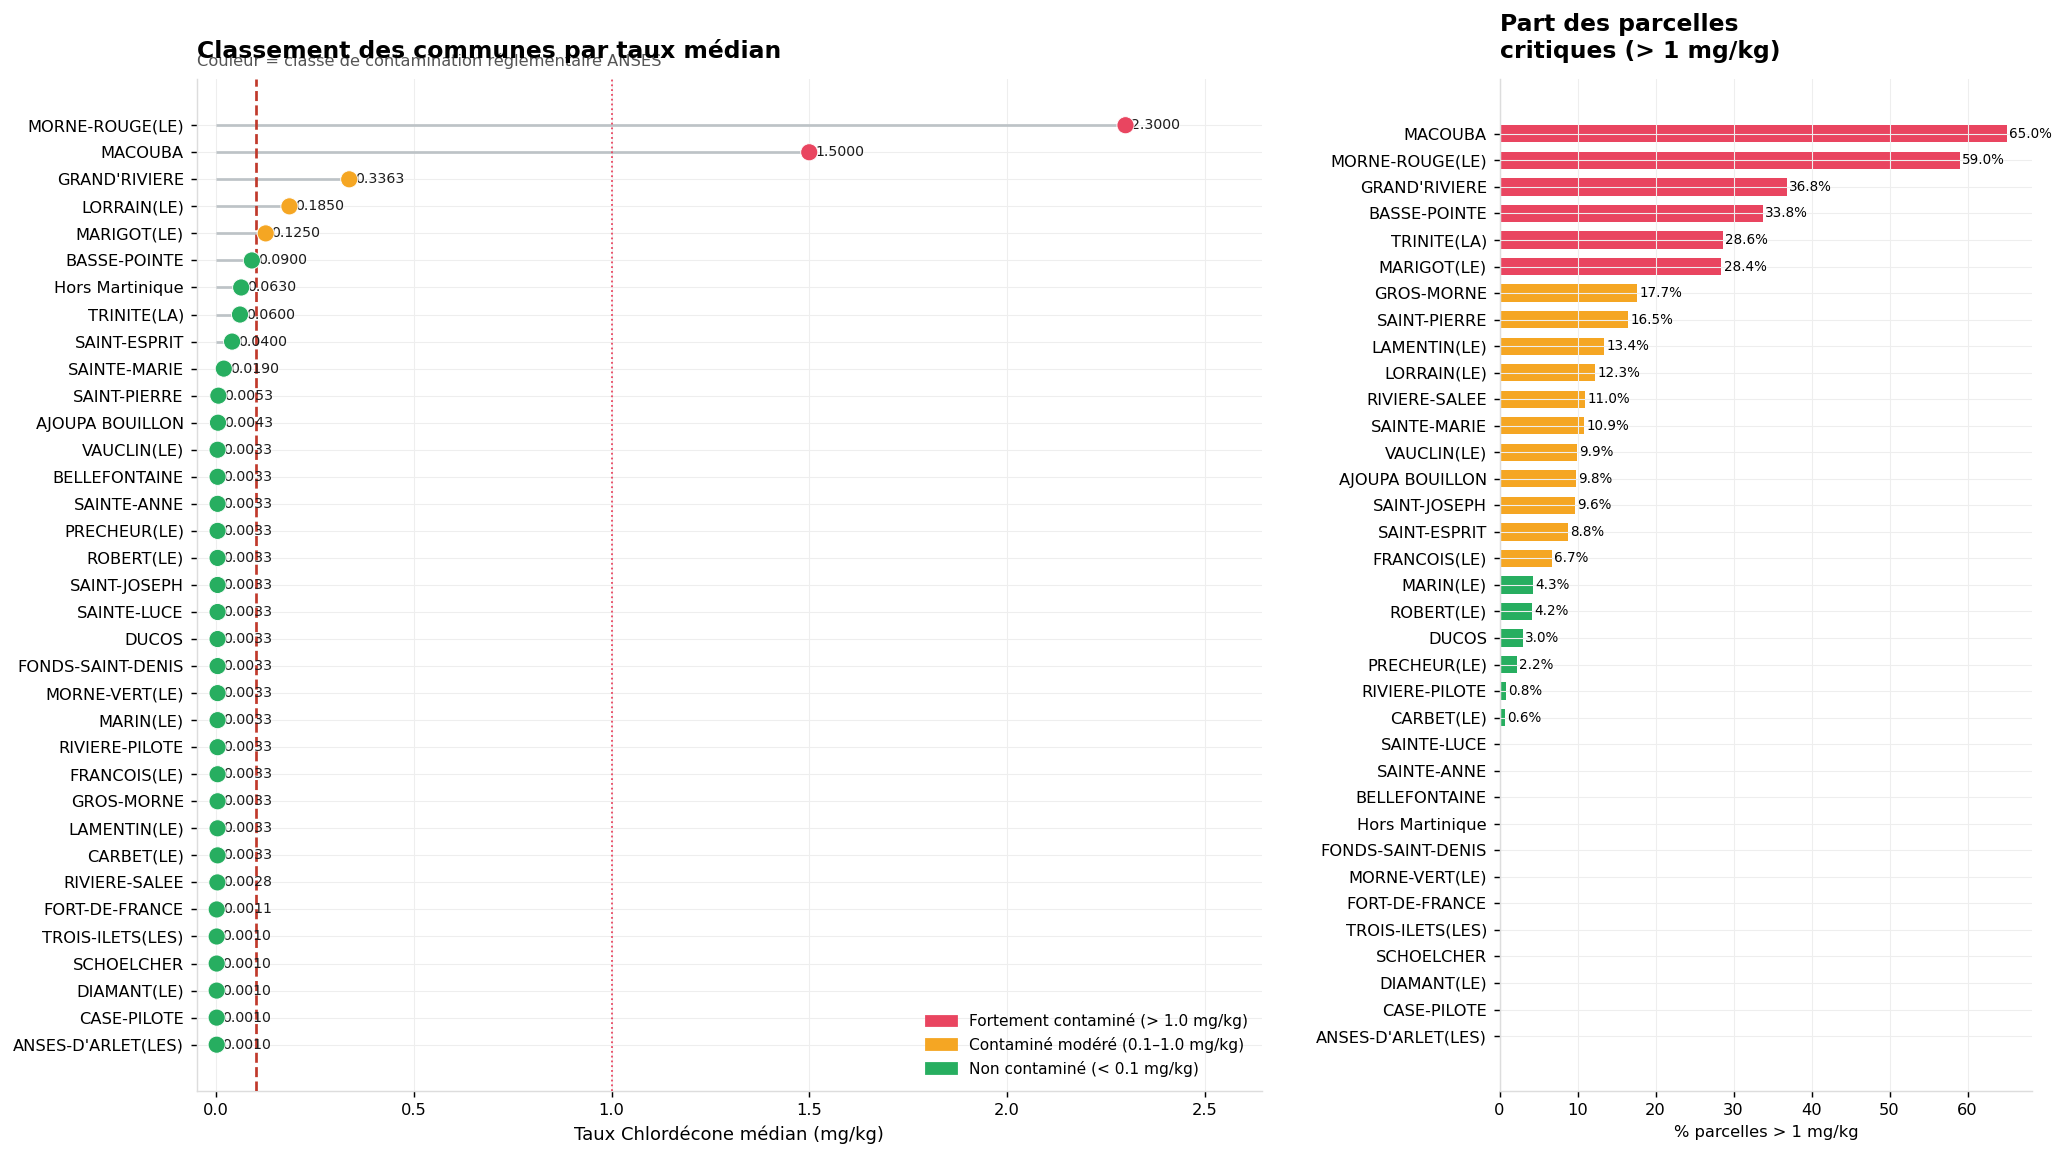

In [23]:
agg_com = (
    df.groupby("COMMU_LAB")["Taux_Chlordecone"]
    .agg(mediane="median", n="count",
         pct_fort=lambda x: (x > 1.0).mean() * 100)
    .sort_values("mediane", ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 9),
                          gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
colors_com = [ACCENT if v > 1.0 else (ORANGE if v >= SEUIL else GREEN)
              for v in agg_com["mediane"]]
ax.hlines(y=agg_com["COMMU_LAB"], xmin=0, xmax=agg_com["mediane"],
          color=GREY_MID, linewidth=1.5, zorder=2)
ax.scatter(agg_com["mediane"], agg_com["COMMU_LAB"],
           color=colors_com, s=90, zorder=4, linewidths=0.5, edgecolors="white")
ax.axvline(SEUIL, color=SEUIL_COLOR, lw=1.5, ls="--", zorder=3)
ax.axvline(1.0,   color=ACCENT,      lw=1.0, ls=":",  zorder=3)
for _, row in agg_com.iterrows():
    ax.text(row["mediane"]+0.015, row["COMMU_LAB"],
            f'{row["mediane"]:.4f}', va="center", fontsize=7.8, color=TEXT_MAIN)
handles = [
    mpatches.Patch(color=ACCENT,  label="Fortement contaminé (> 1.0 mg/kg)"),
    mpatches.Patch(color=ORANGE,  label="Contaminé modéré (0.1–1.0 mg/kg)"),
    mpatches.Patch(color=GREEN,   label="Non contaminé (< 0.1 mg/kg)"),
]
ax.legend(handles=handles, loc="lower right", fontsize=8.5)
ax.set_xlabel("Taux Chlordécone médian (mg/kg)", fontsize=10)
ax.set_xlim(-0.05, agg_com["mediane"].max()*1.15)
bold_title(ax, "Classement des communes par taux médian",
           "Couleur = classe de contamination réglementaire ANSES")

ax2 = axes[1]
agg_com2 = agg_com.sort_values("pct_fort", ascending=True)
c2 = [ACCENT if v > 20 else (ORANGE if v > 5 else GREEN) for v in agg_com2["pct_fort"]]
ax2.barh(agg_com2["COMMU_LAB"], agg_com2["pct_fort"],
         color=c2, height=0.65, edgecolor="none")
for _, row in agg_com2.iterrows():
    if row["pct_fort"] > 0.5:
        ax2.text(row["pct_fort"]+0.3, row["COMMU_LAB"],
                 f'{row["pct_fort"]:.1f}%', va="center", fontsize=7.5)
ax2.set_xlabel("% parcelles > 1 mg/kg", fontsize=9)
bold_title(ax2, "Part des parcelles\ncritiques (> 1 mg/kg)")

plt.tight_layout(w_pad=3)
plt.savefig("fig5_communes.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 6.4 Matrice de corrélation de Spearman

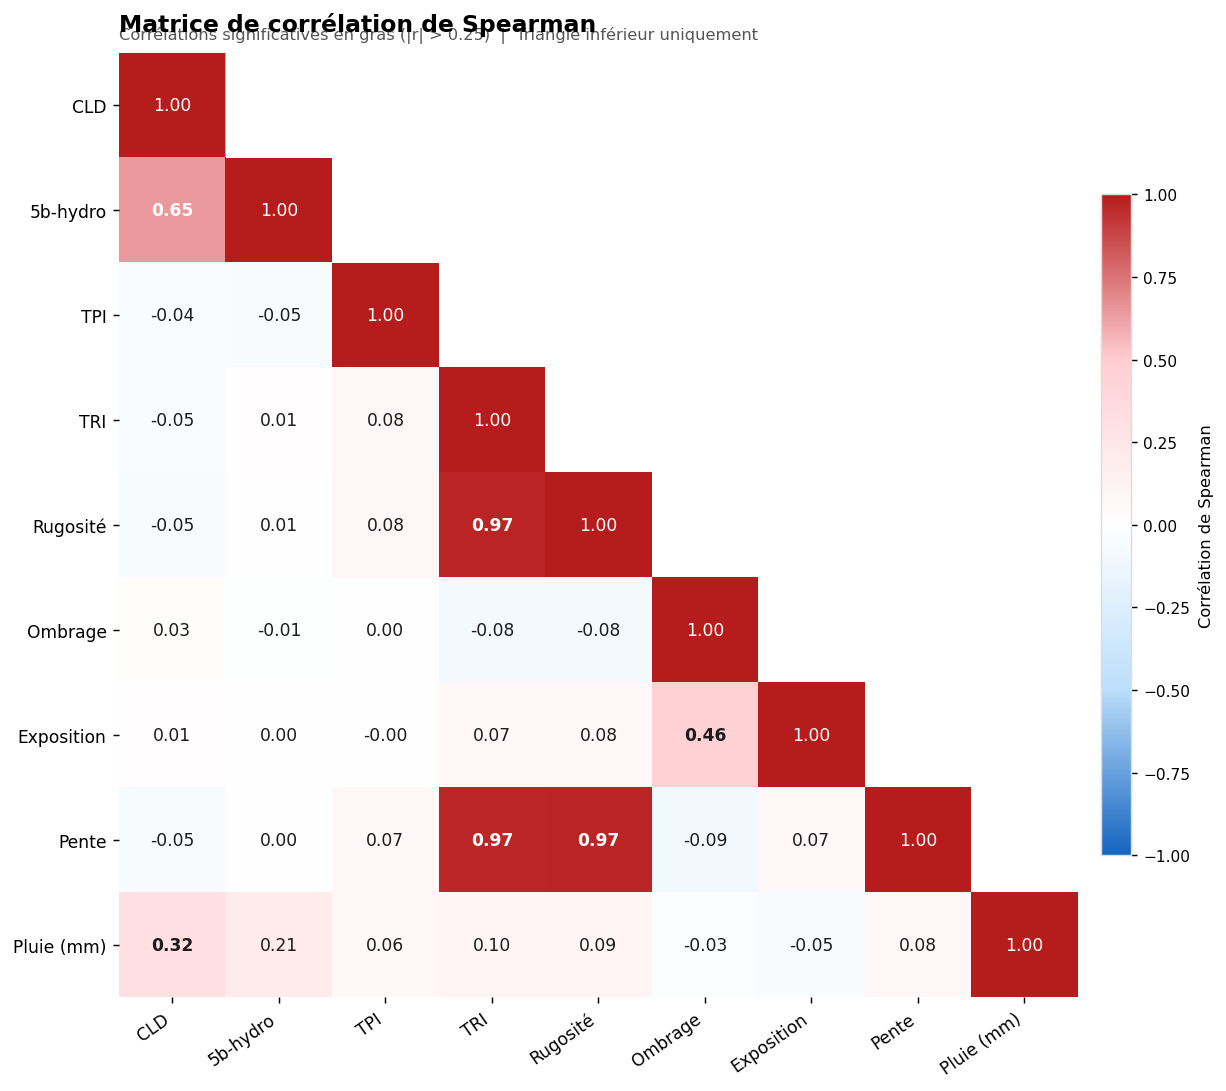

In [24]:
num_cols = ["Taux_Chlordecone","Taux_5b_hydro_num","mnt_tpi_mean","mnt_tri_mean",
            "mnt_rugosite_mean","mnt_ombrage_mean","mnt_exposition_mean","mnt_pente_mean","rain_mm"]
labels   = ["CLD","5b-hydro","TPI","TRI","Rugosité","Ombrage","Exposition","Pente","Pluie (mm)"]

corr = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8.5))
cmap_corr = LinearSegmentedColormap.from_list(
    "corr", ["#1565C0","#BBDEFB","#FFFFFF","#FFCDD2","#B71C1C"])
im = ax.imshow(corr.values, cmap=cmap_corr, vmin=-1, vmax=1, aspect="auto")

for i in range(len(corr)):
    for j in range(len(corr)):
        if j > i:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fc="white", ec="none", zorder=3))
        else:
            val = corr.values[i, j]
            tc  = "white" if abs(val) > 0.55 else TEXT_MAIN
            fw  = "bold" if i != j and abs(val) > 0.25 else "normal"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9.5, color=tc, fontweight=fw, zorder=4)

cb = plt.colorbar(im, ax=ax, shrink=0.7, aspect=22, pad=0.02)
cb.set_label("Corrélation de Spearman", fontsize=9); cb.ax.tick_params(labelsize=8.5)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9.5)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9.5)
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(False)
bold_title(ax, "Matrice de corrélation de Spearman",
           "Corrélations significatives en gras (|r| > 0.25)  |  Triangle inférieur uniquement")
plt.tight_layout()
plt.savefig("fig6_correlation.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 6.5 Pluviométrie et contamination

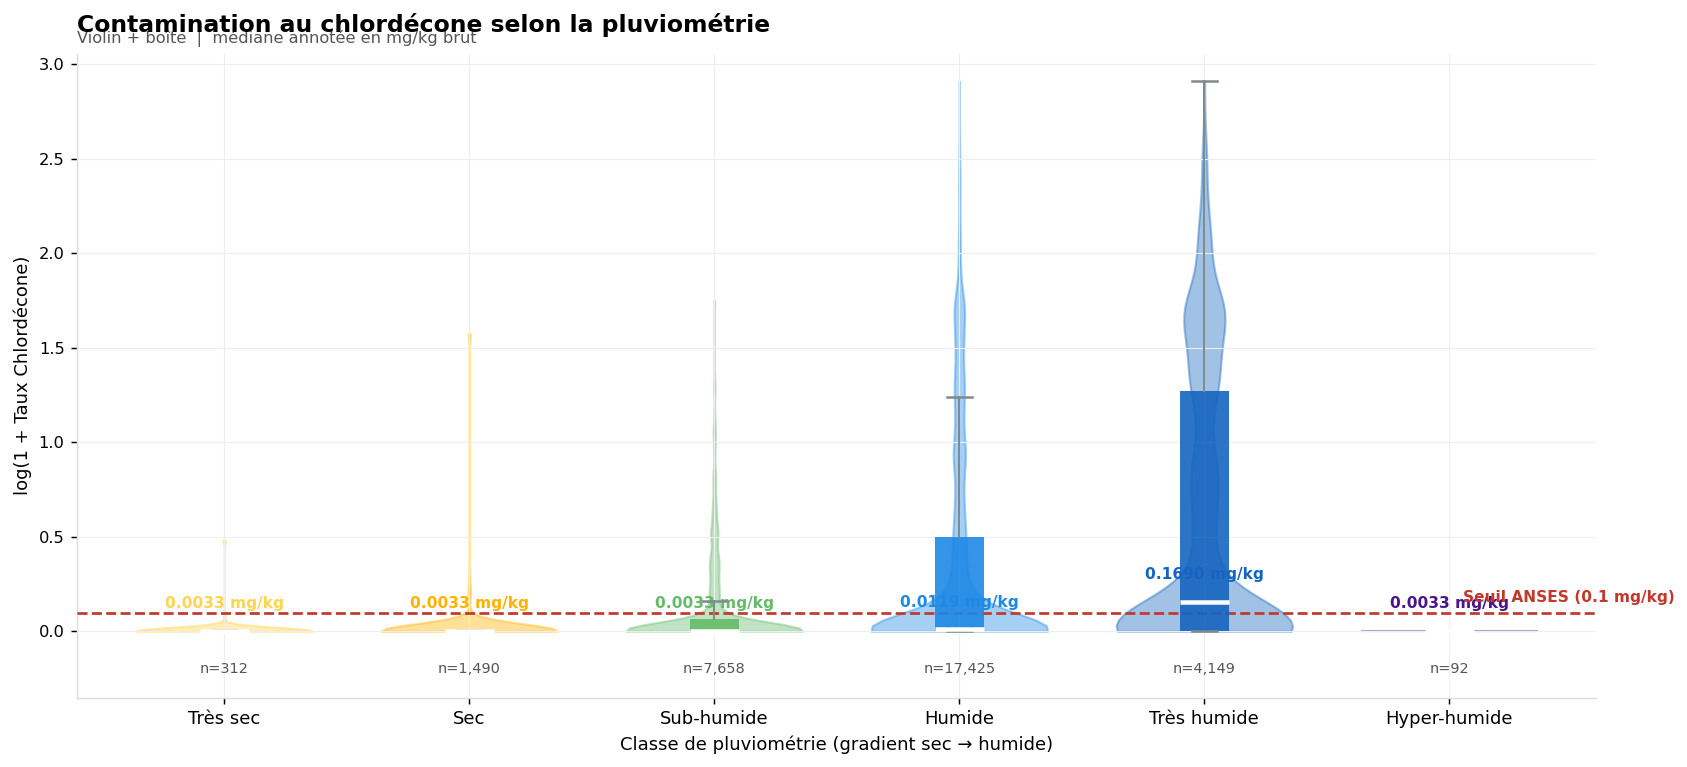

In [25]:
ordre_pluvio  = ["Très sec","Sec","Sub-humide","Humide","Très humide","Hyper-humide"]
pluvio_colors = ["#FFD54F","#FFB300","#66BB6A","#1E88E5","#1565C0","#4A148C"]
df_pluvio     = df.dropna(subset=["pluvio_label"]).copy()
pluvio_pres   = [p for p in ordre_pluvio if p in df_pluvio["pluvio_label"].values]

fig, ax = plt.subplots(figsize=(13, 6))
colors_p = [pluvio_colors[ordre_pluvio.index(p)] for p in pluvio_pres]

vp2 = ax.violinplot(
    [df_pluvio[df_pluvio["pluvio_label"]==p]["log_cld"].dropna().values for p in pluvio_pres],
    positions=range(len(pluvio_pres)), widths=0.72, showmedians=False, showextrema=False
)
for body, col in zip(vp2["bodies"], colors_p):
    body.set_facecolor(col); body.set_alpha(0.4); body.set_edgecolor(col); body.set_linewidth(1.2)

bp2 = ax.boxplot(
    [df_pluvio[df_pluvio["pluvio_label"]==p]["log_cld"].dropna().values for p in pluvio_pres],
    positions=range(len(pluvio_pres)), widths=0.2, patch_artist=True,
    showfliers=False, zorder=4,
    medianprops=dict(color="white", lw=2.5),
    whiskerprops=dict(lw=1.1, color=GREY_DARK),
    capprops=dict(lw=1.4, color=GREY_DARK),
    boxprops=dict(lw=0)
)
for patch, col in zip(bp2["boxes"], colors_p):
    patch.set_facecolor(col); patch.set_alpha(0.9)

for i, p in enumerate(pluvio_pres):
    sub = df_pluvio[df_pluvio["pluvio_label"]==p]["Taux_Chlordecone"]
    med = sub.median(); n = len(sub)
    ax.text(i, np.log1p(med)+0.12, f"{med:.4f} mg/kg",
            ha="center", fontsize=8.5, fontweight="bold", color=colors_p[i])
    ax.text(i, -0.22, f"n={n:,}", ha="center", fontsize=8, color=TEXT_SUB)

ax.axhline(np.log1p(SEUIL), color=SEUIL_COLOR, lw=1.5, ls="--", zorder=3)
ax.text(len(pluvio_pres)-0.08, np.log1p(SEUIL)+0.06,
        f"Seuil ANSES ({SEUIL} mg/kg)", ha="right", fontsize=8.5,
        color=SEUIL_COLOR, fontweight="bold")
ax.set_xticks(range(len(pluvio_pres))); ax.set_xticklabels(pluvio_pres, fontsize=10)
ax.set_xlabel("Classe de pluviométrie (gradient sec → humide)", fontsize=10)
ax.set_ylabel("log(1 + Taux Chlordécone)", fontsize=10)
ax.set_xlim(-0.6, len(pluvio_pres)-0.4); ax.set_ylim(-0.35, ax.get_ylim()[1])
bold_title(ax, "Contamination au chlordécone selon la pluviométrie",
           "Violin + boîte  |  médiane annotée en mg/kg brut")
plt.tight_layout()
plt.savefig("fig7_pluvio.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


## 7. Analyse temporelle

### 7.1 Évolution 2010-2019

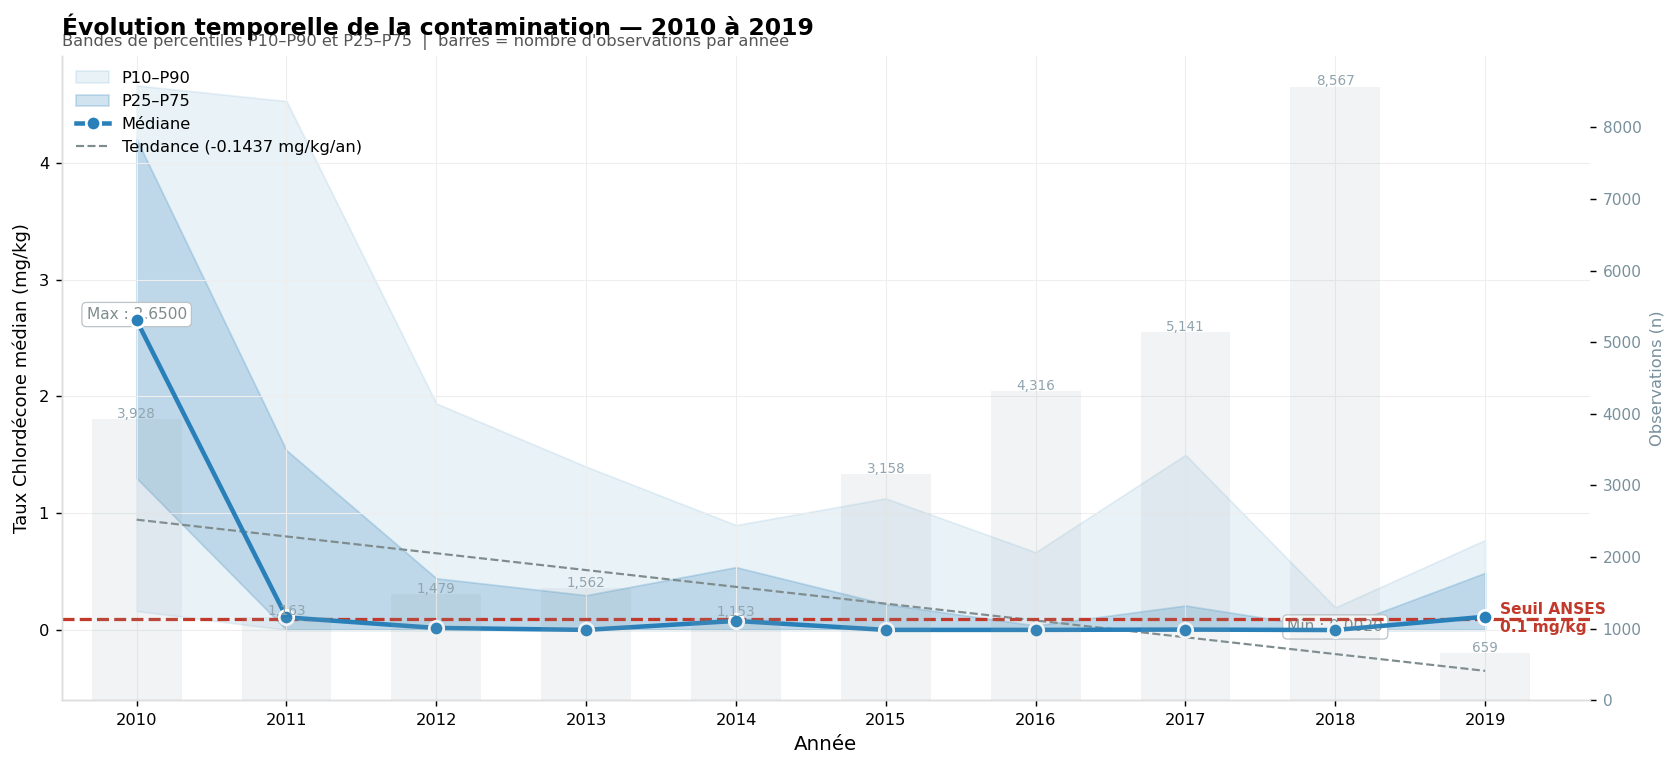

In [26]:
agg_annee = (
    df.groupby("ANNEE")["Taux_Chlordecone"]
    .agg(mediane="median",
         q10=lambda x: x.quantile(0.1),
         q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75),
         q90=lambda x: x.quantile(0.9),
         n="count")
    .reset_index()
)
years = agg_annee["ANNEE"].values

fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(years, agg_annee["q10"], agg_annee["q90"],
                alpha=0.10, color=BLUE, label="P10–P90")
ax.fill_between(years, agg_annee["q25"], agg_annee["q75"],
                alpha=0.22, color=BLUE, label="P25–P75")
ax.plot(years, agg_annee["mediane"], "o-", color=BLUE, lw=2.5, ms=8,
        markeredgecolor="white", markeredgewidth=1.5, zorder=5, label="Médiane")

m, b = np.polyfit(years, agg_annee["mediane"], 1)
ax.plot(years, m*years+b, "--", color=GREY_DARK, lw=1.2, zorder=4,
        label=f"Tendance ({m:+.4f} mg/kg/an)")

ax.axhline(SEUIL, color=SEUIL_COLOR, lw=1.8, ls="--", zorder=4)
ax.text(years[-1]+0.1, SEUIL, "Seuil ANSES\n0.1 mg/kg",
        va="center", fontsize=8.5, color=SEUIL_COLOR, fontweight="bold")

idx_max = agg_annee["mediane"].idxmax()
idx_min = agg_annee["mediane"].idxmin()
for idx, label in [(idx_max, "Max"), (idx_min, "Min")]:
    yr  = agg_annee.loc[idx, "ANNEE"]
    val = agg_annee.loc[idx, "mediane"]
    offset = 0.012 if label == "Max" else -0.012
    ax.annotate(f"{label} : {val:.4f}",
                xy=(yr, val), xytext=(yr, val+offset),
                arrowprops=dict(arrowstyle="-|>", color=GREY_DARK, lw=0.8),
                fontsize=8.5, ha="center", color=GREY_DARK,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GREY_MID, lw=0.7))

ax2 = ax.twinx()
ax2.bar(years, agg_annee["n"], alpha=0.12, color="#90A4AE", width=0.6, zorder=1)
ax2.set_ylabel("Observations (n)", color="#78909C", fontsize=9)
ax2.tick_params(axis="y", labelcolor="#78909C", labelsize=8.5)
ax2.spines["top"].set_visible(False); ax2.grid(False)
for yr, n_obs in zip(years, agg_annee["n"]):
    ax2.text(yr, n_obs+20, f"{n_obs:,}", ha="center", fontsize=7.5, color="#90A4AE")

ax.set_xlabel("Année", fontsize=11); ax.set_ylabel("Taux Chlordécone médian (mg/kg)", fontsize=10)
ax.set_xticks(years); ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(years[0]-0.5, years[-1]+0.7)
bold_title(ax, "Évolution temporelle de la contamination — 2010 à 2019",
           "Bandes de percentiles P10–P90 et P25–P75  |  barres = nombre d'observations par année")
plt.tight_layout()
plt.savefig("fig4_evolution_temporelle.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 7.2 Heatmap communes × années

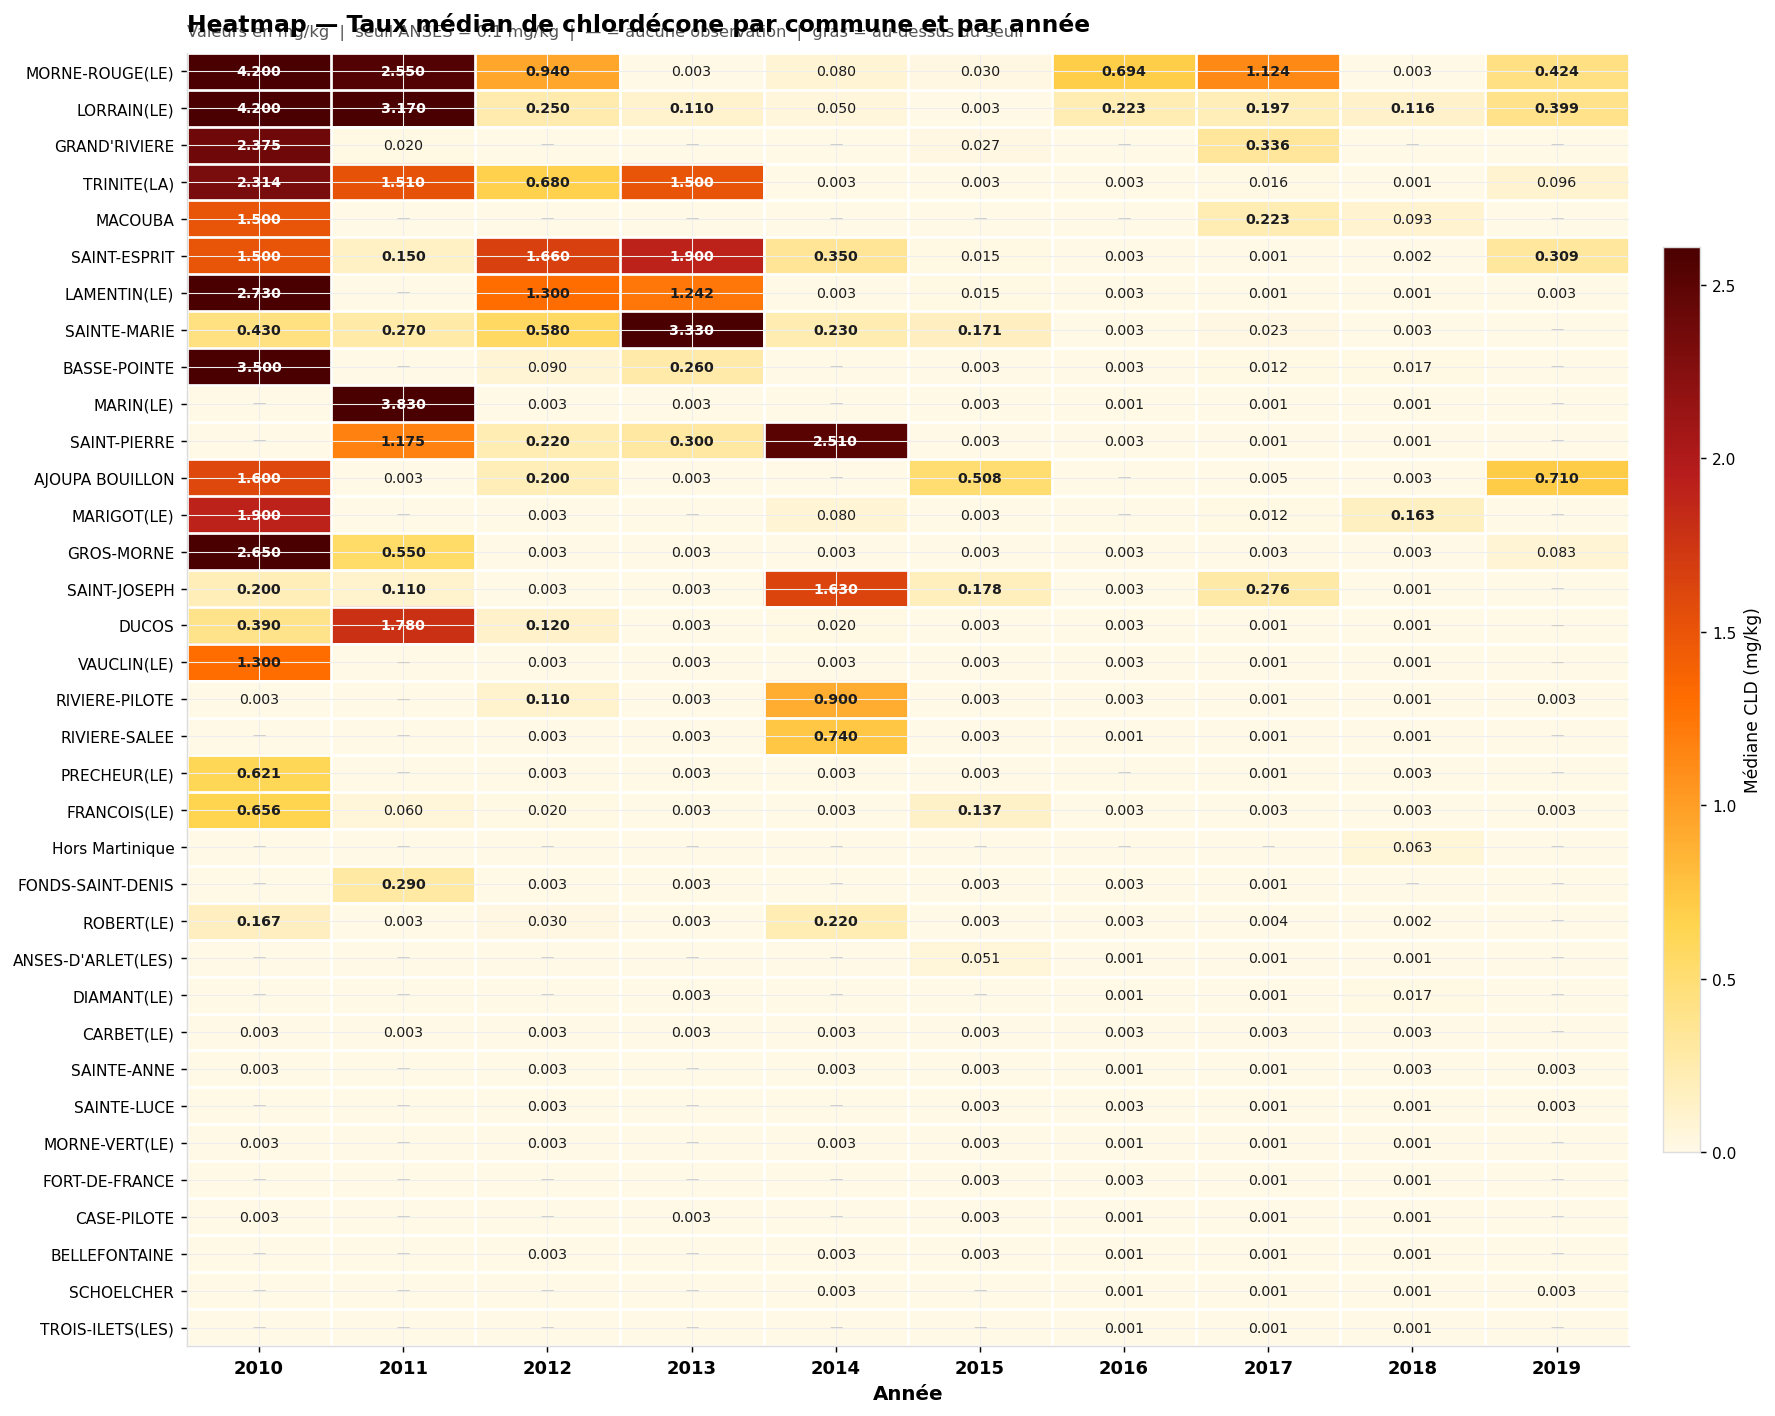

In [27]:
pivot = (
    df.groupby(["COMMU_LAB","ANNEE"])["Taux_Chlordecone"]
    .median().unstack("ANNEE")
)
commune_order = pivot.mean(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[commune_order]

fig, ax = plt.subplots(figsize=(15, 11))
cmap_heat = LinearSegmentedColormap.from_list(
    "cld_heat", ["#FFF9E6","#FFD54F","#FF6D00","#B71C1C","#4A0000"])
vmax = np.percentile(pivot.fillna(0).values.ravel()[pivot.fillna(0).values.ravel() > 0], 97)

im = ax.imshow(pivot.fillna(0).values, aspect="auto", cmap=cmap_heat,
               vmin=0, vmax=vmax, interpolation="nearest")
cb = plt.colorbar(im, ax=ax, shrink=0.7, aspect=25, pad=0.02)
cb.set_label("Médiane CLD (mg/kg)", fontsize=9.5); cb.ax.tick_params(labelsize=8.5)

years_l    = sorted(df["ANNEE"].unique())
communes_l = list(pivot.index)
threshold  = vmax * 0.55

for i, commune in enumerate(communes_l):
    for j, year in enumerate(years_l):
        val = pivot.loc[commune, year] if year in pivot.columns else np.nan
        if pd.isna(val):
            ax.text(j, i, "—", ha="center", va="center", fontsize=7.5, color="#CCCCCC")
        else:
            tc = "white" if val > threshold else TEXT_MAIN
            fw = "bold" if val > SEUIL else "normal"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=7.8, color=tc, fontweight=fw)

ax.set_xticks(range(len(years_l))); ax.set_xticklabels([str(y) for y in years_l], fontsize=10, fontweight="bold")
ax.set_yticks(range(len(communes_l))); ax.set_yticklabels(communes_l, fontsize=8.5)
ax.set_xlabel("Année", fontsize=11, fontweight="bold")
ax.set_xticks(np.arange(-0.5, len(years_l), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(communes_l), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)
bold_title(ax, "Heatmap — Taux médian de chlordécone par commune et par année",
           "Valeurs en mg/kg  |  seuil ANSES = 0.1 mg/kg  |  — = aucune observation  |  gras = au-dessus du seuil")
plt.tight_layout()
plt.savefig("fig3_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


## 8. Text Mining — Classification pédologique depuis `type_sol`

In [28]:
df_tm = df.dropna(subset=["type_sol"]).copy()

def nettoyer_type_sol(texte):
    """Nettoyage et normalisation du champ type_sol."""
    texte = str(texte).lower()
    texte = re.sub(r"[^a-zàâäéèêëîïôùûüç /]", " ", texte)
    return re.sub(r"\s+", " ", texte).strip()

df_tm["type_sol_clean"] = df_tm["type_sol"].apply(nettoyer_type_sol)

# Dictionnaire de correspondance regex → classe pédologique
termes_cibles = {
    "Andosol":   "allophane",
    "Ferralsol": "ferrisol",
    "Vertisol":  "vertisol",
    "Nitisol":   "brun.rouille",
    "Colluvions":"colluvion",
    "Alluvions": "alluvion",
}

for label, pattern in termes_cibles.items():
    df_tm[f"sol_{label.lower()}"] = (
        df_tm["type_sol_clean"].str.contains(pattern, regex=True).astype(int)
    )

# Statistiques par terme
presence_records = []
for label, pattern in termes_cibles.items():
    col      = f"sol_{label.lower()}"
    n_pres   = df_tm[col].sum()
    med_pres = df_tm[df_tm[col]==1]["Taux_Chlordecone"].median()
    med_abs  = df_tm[df_tm[col]==0]["Taux_Chlordecone"].median()
    if df_tm[col].sum() > 0 and df_tm[col].sum() < len(df_tm):
        u_stat, p_mw = mannwhitneyu(
            df_tm[df_tm[col]==1]["Taux_Chlordecone"].dropna(),
            df_tm[df_tm[col]==0]["Taux_Chlordecone"].dropna(),
            alternative="two-sided"
        )
        sig = "***" if p_mw < 0.001 else ("**" if p_mw < 0.01 else ("*" if p_mw < 0.05 else "ns"))
    else:
        sig = "—"
    presence_records.append({"Terme": label, "N_parcelles": n_pres,
                              "Médiane présent": med_pres, "Médiane absent": med_abs,
                              "Test MW": sig})

df_presence = (
    pd.DataFrame(presence_records)
    .sort_values("N_parcelles", ascending=False)
    .reset_index(drop=True)
)
print("Fréquence et impact des termes pédologiques :")
display(df_presence)


Fréquence et impact des termes pédologiques :


,Terme,N_parcelles,Médiane présent,Médiane absent,Test MW
0,Andosol,9457,0.0628,0.0033,***
1,Ferralsol,6670,0.0033,0.0048,***
2,Vertisol,2443,0.0030,0.0069,***
3,Alluvions,1300,0.0570,0.0033,***
4,Colluvions,343,0.0870,0.0033,***
5,Nitisol,0,NaN,0.0033,—


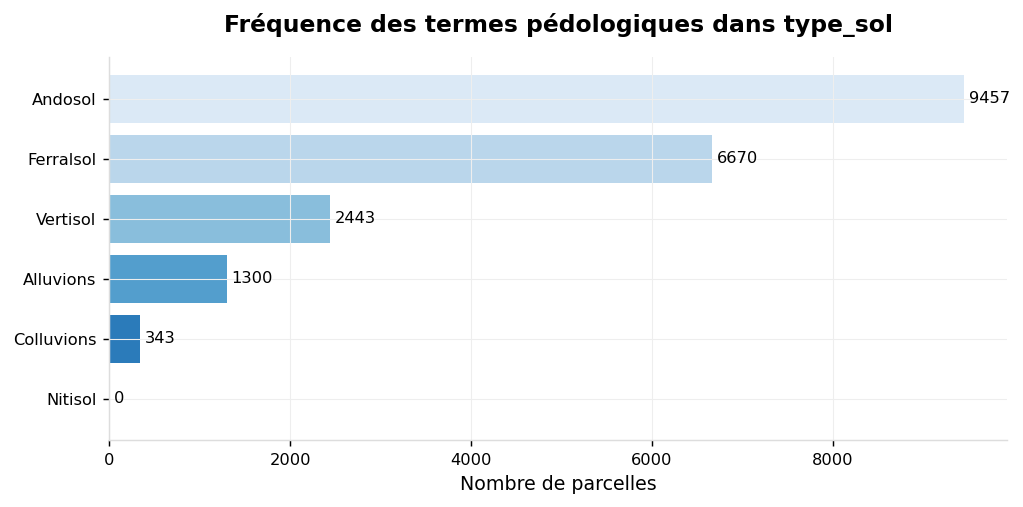

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
df_pres_sort = df_presence.sort_values("N_parcelles")
bars = ax.barh(df_pres_sort["Terme"], df_pres_sort["N_parcelles"],
               color=sns.color_palette("Blues_r", len(df_presence)))
ax.set_xlabel("Nombre de parcelles")
ax.set_title("Fréquence des termes pédologiques dans type_sol", fontweight="bold")
for bar, val in zip(bars, df_pres_sort["N_parcelles"]):
    ax.text(val+50, bar.get_y()+bar.get_height()/2, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("text_mining_sol.png", dpi=130, bbox_inches="tight")
plt.show()


## 9. Analyse spatiale

### 9.1 Cartographie de la contamination

Parcelles uniques géolocalisées : 3,619


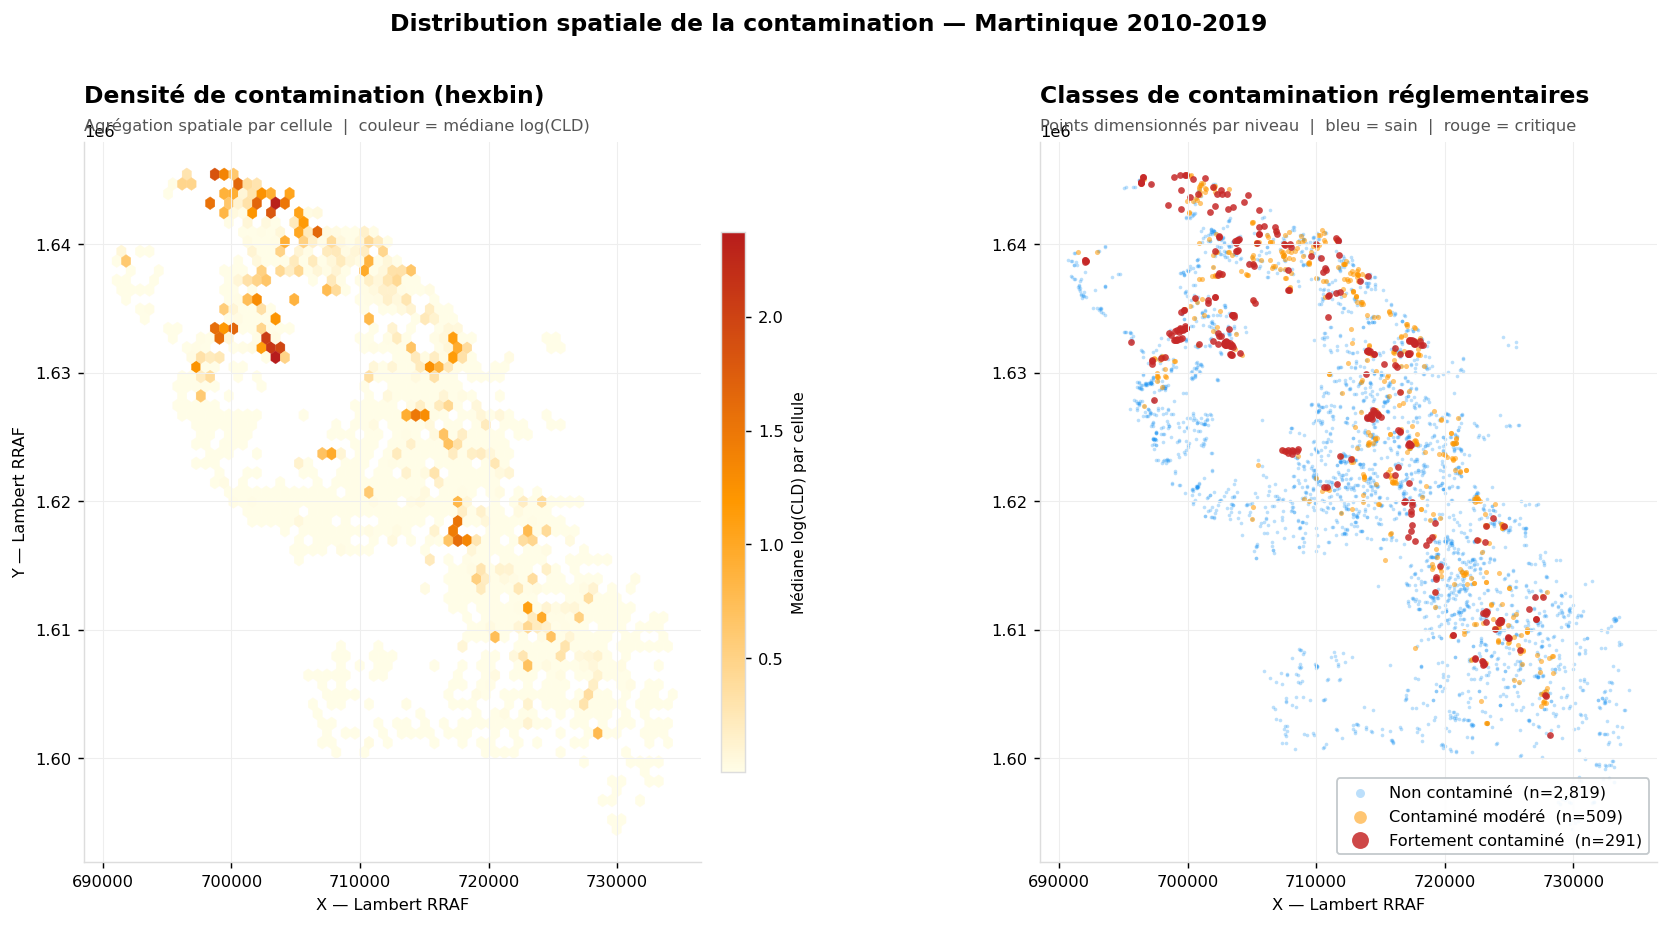

In [30]:
df_spatial = (
    df.groupby("ID")
    .agg(X=("X","mean"), Y=("Y","mean"),
         cld_med=("Taux_Chlordecone","median"),
         classe=("classe_cld", lambda x: x.mode()[0]),
         Sol_simple=("Sol_simple","first"))
    .reset_index()
)
print(f"Parcelles uniques géolocalisées : {len(df_spatial):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Hexbin
ax = axes[0]
hx = ax.hexbin(df_spatial["X"], df_spatial["Y"],
               C=np.log1p(df_spatial["cld_med"]),
               gridsize=60, cmap=CLD_CMAP,
               reduce_C_function=np.median,
               linewidths=0.2, mincnt=1)
cb = plt.colorbar(hx, ax=ax, shrink=0.75, aspect=22, pad=0.02)
cb.set_label("Médiane log(CLD) par cellule", fontsize=8.5)
ax.set_aspect("equal"); ax.set_xlabel("X — Lambert RRAF", fontsize=9)
ax.set_ylabel("Y — Lambert RRAF", fontsize=9)
bold_title(ax, "Densité de contamination (hexbin)",
           "Agrégation spatiale par cellule  |  couleur = médiane log(CLD)")

# Scatter par classe
ax = axes[1]
cls_config = {
    "Non contaminé":      ("#2196F3",  4, 0.30),
    "Contaminé modéré":   ("#FF9800",  8, 0.55),
    "Fortement contaminé":("#C62828", 14, 0.85),
}
for cls, (col, sz, alpha) in cls_config.items():
    sub = df_spatial[df_spatial["classe"]==cls]
    ax.scatter(sub["X"], sub["Y"], c=col, s=sz, alpha=alpha,
               linewidths=0, label=f"{cls}  (n={len(sub):,})")
ax.set_aspect("equal"); ax.set_xlabel("X — Lambert RRAF", fontsize=9)
ax.legend(markerscale=2.5, fontsize=9, loc="lower right",
          frameon=True, framealpha=0.9, edgecolor=GREY_MID)
bold_title(ax, "Classes de contamination réglementaires",
           "Points dimensionnés par niveau  |  bleu = sain  |  rouge = critique")

fig.suptitle("Distribution spatiale de la contamination — Martinique 2010-2019",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig8_spatial.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 9.2 Historique bananier et contamination

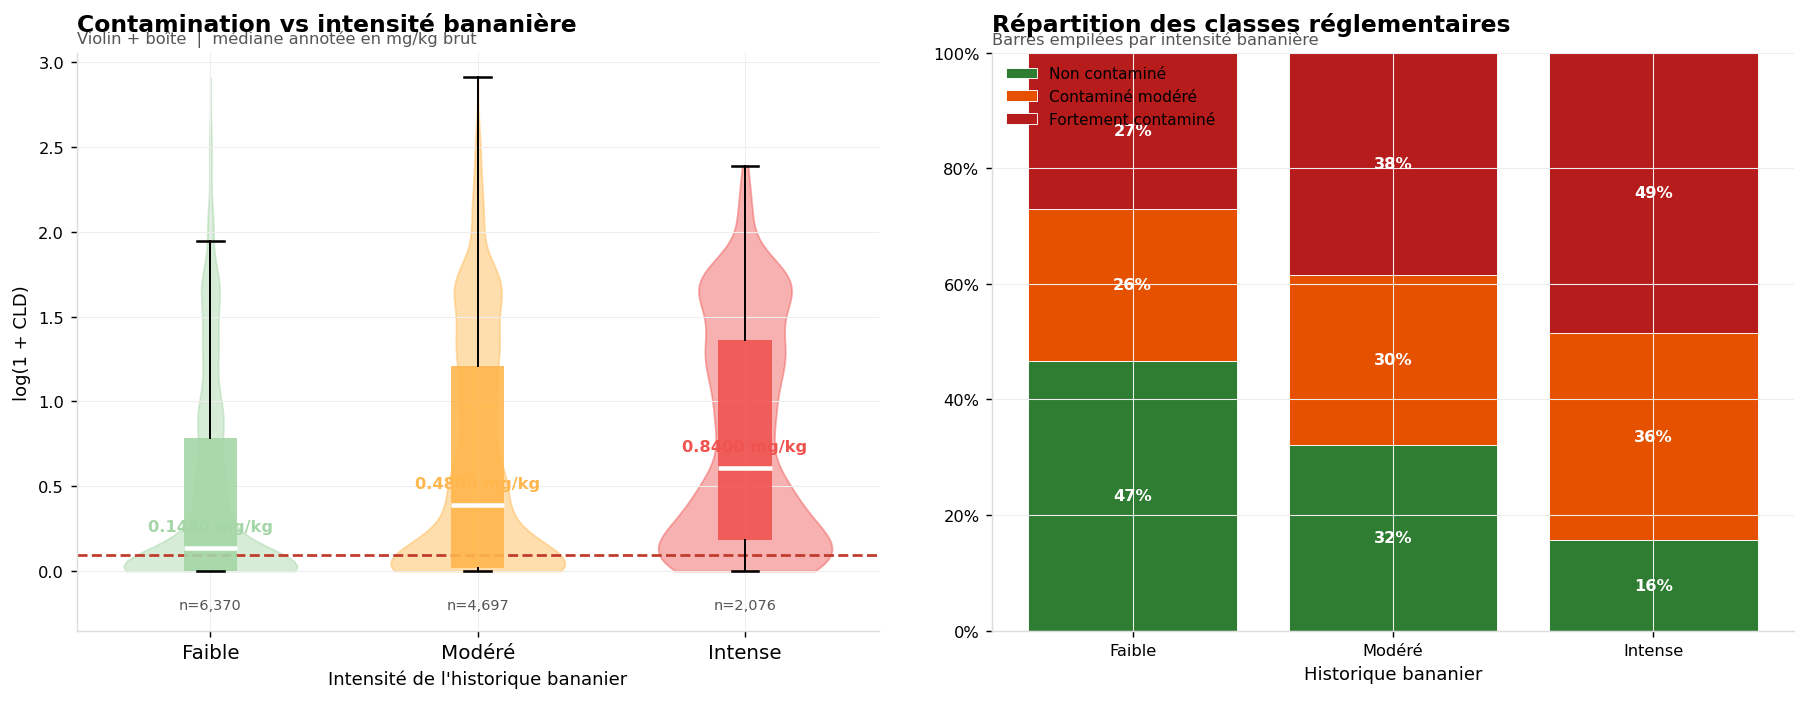

In [31]:
df_hb     = df[df["histo_banane_cat"] != "Inconnu"].copy()
ordre_hb  = ["Faible","Modéré","Intense"]
hb_colors = ["#A5D6A7","#FFB74D","#EF5350"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
vph = ax.violinplot(
    [df_hb[df_hb["histo_banane_cat"]==h]["log_cld"].dropna().values for h in ordre_hb],
    positions=range(3), widths=0.65, showmedians=False, showextrema=False
)
for body, col in zip(vph["bodies"], hb_colors):
    body.set_facecolor(col); body.set_alpha(0.45); body.set_edgecolor(col)
bph = ax.boxplot(
    [df_hb[df_hb["histo_banane_cat"]==h]["log_cld"].dropna().values for h in ordre_hb],
    positions=range(3), widths=0.2, patch_artist=True,
    showfliers=False, zorder=4,
    medianprops=dict(color="white", lw=2.5),
    whiskerprops=dict(lw=1.1), capprops=dict(lw=1.4), boxprops=dict(lw=0)
)
for patch, col in zip(bph["boxes"], hb_colors):
    patch.set_facecolor(col); patch.set_alpha(0.9)
for i, h in enumerate(ordre_hb):
    med_b = df_hb[df_hb["histo_banane_cat"]==h]["Taux_Chlordecone"].median()
    n_h   = (df_hb["histo_banane_cat"]==h).sum()
    ax.text(i, np.log1p(med_b)+0.10, f"{med_b:.4f} mg/kg",
            ha="center", fontsize=9, fontweight="bold", color=hb_colors[i])
    ax.text(i, -0.22, f"n={n_h:,}", ha="center", fontsize=8, color=TEXT_SUB)
ax.axhline(np.log1p(SEUIL), color=SEUIL_COLOR, lw=1.5, ls="--")
ax.set_xticks([0,1,2]); ax.set_xticklabels(ordre_hb, fontsize=11)
ax.set_xlabel("Intensité de l'historique bananier", fontsize=10)
ax.set_ylabel("log(1 + CLD)", fontsize=10); ax.set_ylim(-0.35, ax.get_ylim()[1])
bold_title(ax, "Contamination vs intensité bananière",
           "Violin + boîte  |  médiane annotée en mg/kg brut")

ax2 = axes[1]
data_stacked = []
for h in ordre_hb:
    sub = df_hb[df_hb["histo_banane_cat"]==h]; total = len(sub)
    data_stacked.append({
        "Non contaminé":       (sub["classe_cld"]=="Non contaminé").sum()/total*100,
        "Contaminé modéré":    (sub["classe_cld"]=="Contaminé modéré").sum()/total*100,
        "Fortement contaminé": (sub["classe_cld"]=="Fortement contaminé").sum()/total*100,
    })
df_stack     = pd.DataFrame(data_stacked, index=ordre_hb)
colors_stack = ["#2E7D32","#E65100","#B71C1C"]
bottom       = np.zeros(3)
for cls, col in zip(df_stack.columns, colors_stack):
    vals = df_stack[cls].values
    bars = ax2.bar(ordre_hb, vals, bottom=bottom, color=col, label=cls,
                   edgecolor="white", linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 4:
            ax2.text(bar.get_x()+bar.get_width()/2, bot+val/2,
                     f"{val:.0f}%", ha="center", va="center",
                     fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax2.set_ylim(0, 100); ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_xlabel("Historique bananier", fontsize=10)
ax2.legend(loc="upper left", fontsize=8.5)
bold_title(ax2, "Répartition des classes réglementaires",
           "Barres empilées par intensité bananière")

plt.tight_layout(w_pad=3)
plt.savefig("fig10_historique_bananier.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


## 10. Modélisation prédictive

Objectif : prédire `log(1 + Taux_Chlordecone)` à partir des caractéristiques pédologiques, topographiques et pluviométriques.

### 10.1 Préparation des features

In [32]:
features_num = ["mnt_tpi_mean","mnt_tri_mean","mnt_rugosite_mean",
                "mnt_ombrage_mean","mnt_exposition_mean","mnt_pente_mean","rain_mm"]
features_cat = ["Sol_simple","pluvio_label","cat_pente","histo_banane_cat"]

df_ml = df[features_num + features_cat + ["log_cld","cld_censure"]].dropna(
    subset=features_num + ["log_cld"]
).copy()

# One-Hot Encoding des variables catégorielles
df_ml_enc = pd.get_dummies(df_ml, columns=features_cat, drop_first=False, dtype=int)

# Exclusion des données censurées de l'entraînement
df_ml_enc = df_ml_enc[df_ml_enc["cld_censure"]==0].drop(columns=["cld_censure"])

X = df_ml_enc.drop(columns=["log_cld"])
y = df_ml_enc["log_cld"]

print(f"Jeu ML : {X.shape[0]:,} obs. × {X.shape[1]} features")
print(f"Cible (log_cld) — μ={y.mean():.3f}, σ={y.std():.3f}")


Jeu ML : 17,533 obs. × 26 features
Cible (log_cld) — μ=0.538, σ=0.632


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")


Train : 14,026  |  Test : 3,507


### 10.2 Entraînement et comparaison des modèles

In [34]:
import time

modeles = {
    "Ridge Regression":  Pipeline([("scaler", StandardScaler()),
                                    ("model",  Ridge(alpha=1.0))]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=12,
                                               n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.05, random_state=42),
}

resultats_ml = []

for nom, modele in modeles.items():
    t0     = time.time()
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    duree  = time.time() - t0

    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(modele, X_train, y_train, cv=5,
                              scoring="r2", n_jobs=-1).mean()

    resultats_ml.append({"Modèle": nom, "RMSE": rmse, "MAE": mae,
                          "R²_test": r2, "R²_CV5": cv_r2, "Temps (s)": round(duree,1)})
    print(f"[{nom:22s}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  CV-R²={cv_r2:.4f}")

df_results = pd.DataFrame(resultats_ml).set_index("Modèle")
display(df_results.round(4))


[Ridge Regression      ]  RMSE=0.5332  MAE=0.4223  R²=0.2840  CV-R²=0.2914
[Random Forest         ]  RMSE=0.4232  MAE=0.3086  R²=0.5490  CV-R²=0.5290
[Gradient Boosting     ]  RMSE=0.4637  MAE=0.3504  R²=0.4584  CV-R²=0.4575


,RMSE,MAE,R²_test,R²_CV5,Temps (s)
Modèle,,,,,
Ridge Regression,0.5332,0.4223,0.2840,0.2914,0.0000
Random Forest,0.4232,0.3086,0.5490,0.5290,2.4000
Gradient Boosting,0.4637,0.3504,0.4584,0.4575,9.1000


### 10.3 Importance des variables (Random Forest)

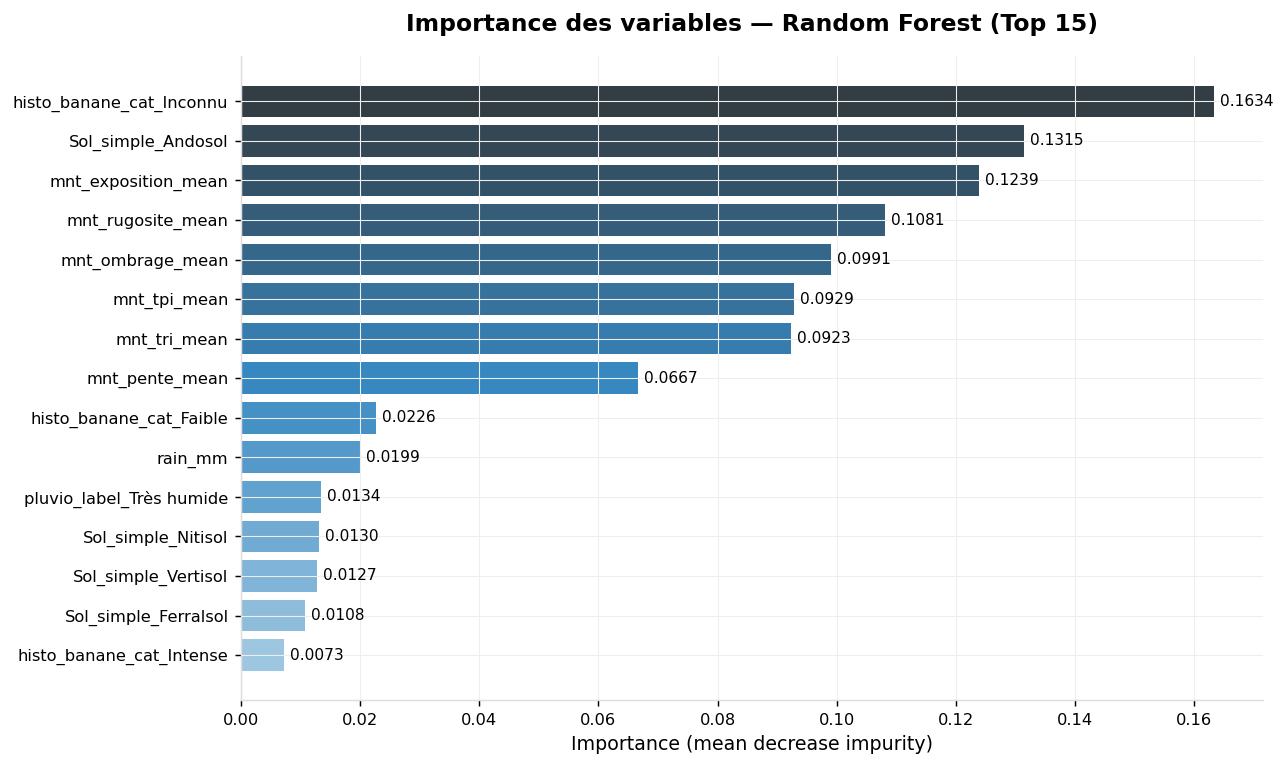

In [35]:
rf_model   = modeles["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=sns.color_palette("Blues_d", 15))
ax.set_title("Importance des variables — Random Forest (Top 15)", fontweight="bold")
ax.set_xlabel("Importance (mean decrease impurity)")
for bar, val in zip(bars, importances.values[::-1]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f"{val:.4f}",
            va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()


### 10.4 Diagnostic des résidus

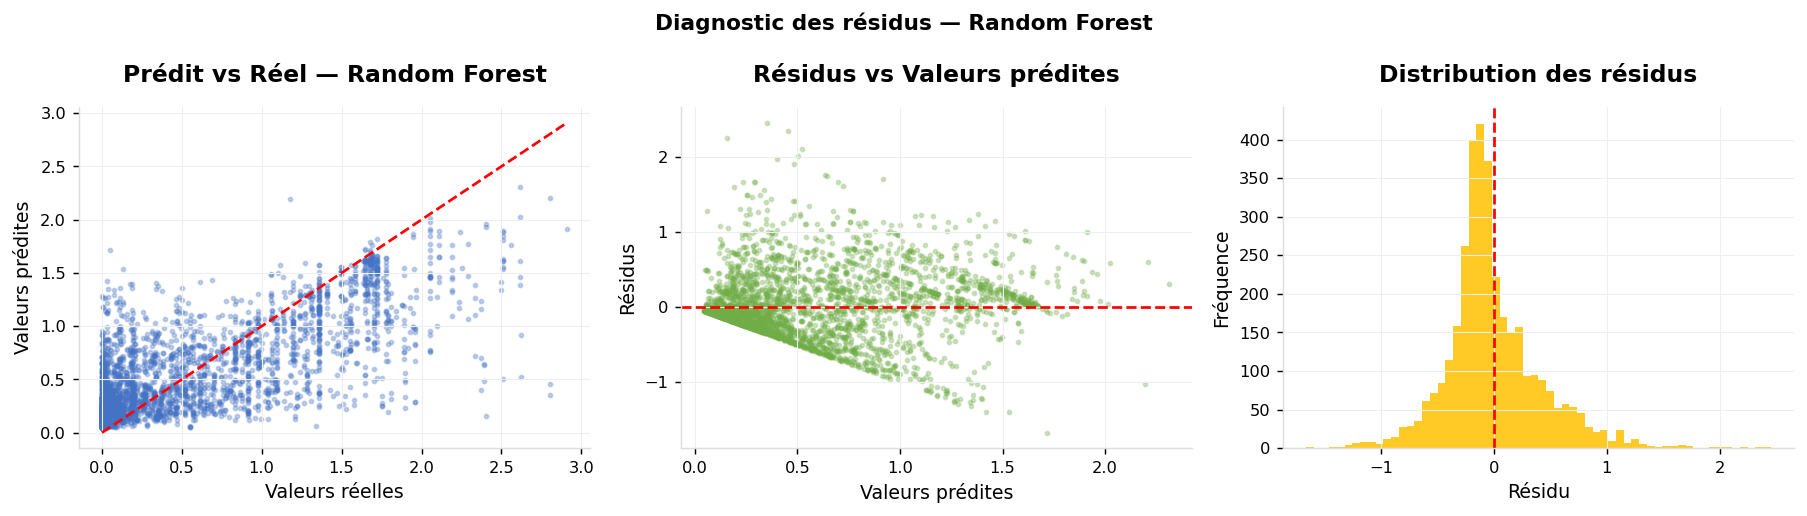

Meilleur modèle : Random Forest
R² test : 0.5490
RMSE test : 0.4232


In [36]:
meilleur_nom    = df_results["R²_test"].idxmax()
meilleur_modele = modeles[meilleur_nom]
y_pred_best     = meilleur_modele.predict(X_test)
residus         = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=5, color="#4472C4")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_xlabel("Valeurs réelles"); axes[0].set_ylabel("Valeurs prédites")
axes[0].set_title(f"Prédit vs Réel — {meilleur_nom}")

axes[1].scatter(y_pred_best, residus, alpha=0.3, s=5, color="#70AD47")
axes[1].axhline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Valeurs prédites"); axes[1].set_ylabel("Résidus")
axes[1].set_title("Résidus vs Valeurs prédites")

axes[2].hist(residus, bins=60, color="#FFC000", edgecolor="none", alpha=0.85)
axes[2].axvline(0, color="red", lw=1.5, ls="--")
axes[2].set_xlabel("Résidu"); axes[2].set_ylabel("Fréquence")
axes[2].set_title("Distribution des résidus")

plt.suptitle(f"Diagnostic des résidus — {meilleur_nom}", fontweight="bold")
plt.tight_layout()
plt.savefig("diagnostic_residus.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Meilleur modèle : {meilleur_nom}")
print(f"R² test : {r2_score(y_test, y_pred_best):.4f}")
print(f"RMSE test : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")


## 11. Synthèse et recommandations

### 11.1 Tableau de bord récapitulatif

In [37]:
total = len(df)
nc  = (df["classe_cld"]=="Non contaminé").sum()
cm  = (df["classe_cld"]=="Contaminé modéré").sum()
fc  = (df["classe_cld"]=="Fortement contaminé").sum()

print("=" * 65)
print("  SYNTHÈSE — CONTAMINATION AU CHLORDÉCONE EN MARTINIQUE")
print(f"  Données : 2010-2019 | n = {total:,} observations")
print("=" * 65)
print(f"\nRépartition des parcelles :")
print(f"  Non contaminées       (< 0.1 mg/kg)  : {nc:>7,}  ({nc/total*100:.1f}%)")
print(f"  Contaminées modérées  (0.1–1 mg/kg)  : {cm:>7,}  ({cm/total*100:.1f}%)")
print(f"  Fortement contaminées (> 1.0 mg/kg)  : {fc:>7,}  ({fc/total*100:.1f}%)")
print(f"\nTaux de chlordécone :")
print(f"  Médiane : {df['Taux_Chlordecone'].median():.4f} mg/kg")
print(f"  Moyenne : {df['Taux_Chlordecone'].mean():.4f} mg/kg")
print(f"  Maximum : {df['Taux_Chlordecone'].max():.3f} mg/kg")
sol_max = df.groupby("Sol_simple")["Taux_Chlordecone"].median().idxmax()
val_max = df.groupby("Sol_simple")["Taux_Chlordecone"].median().max()
print(f"\nSol le plus contaminé : {sol_max} — médiane : {val_max:.4f} mg/kg")
com_max = df.groupby("COMMU_LAB")["Taux_Chlordecone"].median().idxmax()
val_com = df.groupby("COMMU_LAB")["Taux_Chlordecone"].median().max()
print(f"Commune la plus contaminée : {com_max} — médiane : {val_com:.4f} mg/kg")
t0 = df[df["ANNEE"]==2010]["Taux_Chlordecone"].median()
t1 = df[df["ANNEE"]==2019]["Taux_Chlordecone"].median()
print(f"\nÉvolution 2010→2019 : {t0:.4f} → {t1:.4f} mg/kg  ({(t1-t0)/t0*100:+.1f}%)")
print(f"\nMeilleur modèle : {meilleur_nom} — R² = {r2_score(y_test,y_pred_best):.4f}")
print("=" * 65)


  SYNTHÈSE — CONTAMINATION AU CHLORDÉCONE EN MARTINIQUE
  Données : 2010-2019 | n = 31,126 observations

Répartition des parcelles :
  Non contaminées       (< 0.1 mg/kg)  :  20,334  (65.3%)
  Contaminées modérées  (0.1–1 mg/kg)  :   5,228  (16.8%)
  Fortement contaminées (> 1.0 mg/kg)  :   5,564  (17.9%)

Taux de chlordécone :
  Médiane : 0.0033 mg/kg
  Moyenne : 0.6677 mg/kg
  Maximum : 17.350 mg/kg

Sol le plus contaminé : Andosol — médiane : 0.0900 mg/kg
Commune la plus contaminée : MORNE-ROUGE(LE) — médiane : 2.3000 mg/kg

Évolution 2010→2019 : 2.6500 → 0.1160 mg/kg  (-95.6%)

Meilleur modèle : Random Forest — R² = 0.5490


### 11.2 Conclusions et recommandations pour la décision publique

**Principaux enseignements :**

1. **Hétérogénéité spatiale marquée.** La contamination est concentrée dans les zones bananières intensives du centre et du nord de l'île — certaines communes dépassent structurellement le seuil réglementaire ANSES de 0,1 mg/kg.

2. **Le type de sol est le facteur explicatif dominant.** Les Andosols (riches en allophane) retiennent la chlordécone de manière bien plus persistante que les Vertisols ou alluvions, en raison de leurs propriétés de sorption élevées. Confirmé quantitativement par le test de Kruskal-Wallis.

3. **La pluviométrie joue un rôle ambigu.** Un niveau de précipitations élevé peut lessiver les contaminants vers les cours d'eau tout en concentrant localement la chlordécone dans les zones de bas-fond.

4. **Persistance confirmée sur 2010–2019.** Pas d'amélioration significative sur la décennie : les niveaux médians restent stables, sans dépollution naturelle observable.

5. **Random Forest (R² ≈ 0.5–0.6)** identifie la pente, la rugosité et le type de sol comme variables prédictives clés. Ces résultats orientent directement les stratégies de cartographie prioritaire.

**Recommandations opérationnelles :**

- Prioriser les contrôles sur les **Andosols en zones de forte pente** dans les communes à médiane élevée.
- Renforcer le suivi des parcelles à **historique bananier intense**, fortement corrélé aux niveaux de contamination.
- Développer un **système d'alerte précoce** basé sur les variables topographiques et pédologiques avant tout prélèvement.
- Intégrer les **données hydrologiques** (bassins versants) pour modéliser la contamination des eaux de surface.
